"""
============================================================================
Asignatura : Computación Bioinspirada
Semana     : 1
Tema       : Lógica Difusa y Algoritmos de Adaptación Social
Fecha      : 08-03-2026
Grupo No.  : 2

Autores
-----------------------
1. Sánchez Mendieta Juan Pablo
2. Rodríguez Vélez Ximena Jhoana
3. Viteri Ayala Flavia Kamila

Estructura del notebook
-----------------------
1. Experimentación con lógica difusa:
 a. Control de derrape
 b. Aplicación en entorno de trabajo
2. Experimentación con algoritmo PSO

============================================================================
"""

"""
# Sección 1: Experimentación con lógica difusa

La lógica difusa extiende la lógica booleana permitiendo que una variable  
pertenezca a un conjunto con un grado de membresía μ ∈ [0, 1].

El pipeline de un sistema de control difuso consta de cuatro etapas:

1. Fuzzificación — convertir valores nítidos en grados de membresía.  
2. Evaluación de reglas — aplicar las reglas IF–THEN usando operadores difusos (min/max).  
3. Agregación — combinar las salidas de todas las reglas activas.  
4. Defuzzificación — convertir el conjunto difuso de salida en un valor nítido.

"""

In [102]:
# ==============================================================
# Librerías y configuración
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

# Reproducibilidad
np.random.seed(42) # Reproducibilidad de resultados aleatorios

# Estilo de gráficos
plt.rcParams.update({
    "figure.dpi": 110,    # Resolución de la figura
    "axes.grid": True,    # Cuadrícula activada  
    "grid.alpha": 0.3,    # Cuadrícula semitransparente
    "font.size": 10,
})

print("Configuración ejecutada.")

Configuración ejecutada.


In [103]:
# =================================================================================
# Funciones de membresía (MF)
# 
# Se crean las funciones de membresía (MF) que van a asignar un
# valor (grado de pertenencia) μ ∈ [0, 1] al un conjunto 
# lingüístico que definiremos (p.ej. "leve", "fuerte").

# Se implementan dos formas canónicas:
#   - Triangular (trimf): útil para categorías intermedias con pico bien definido.
#   - Trapezoidal (trapmf): útil para categorías extremas con zona plana (μ = 1).
# =================================================================================

def trimf(x: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
    """
    Función de membresía TRIANGULAR.

    Parámetros
    ---------------
    x : array de valores de entrada (universo de discurso)
    a : punto donde la función empieza a subir (μ = 0 para x ≤ a)
    b : punto pico donde μ = 1
    c : punto donde la función termina de bajar (μ = 0 para x ≥ c)

    Retorna
    ---------------
    Array de valores μ ∈ [0, 1] para cada elemento de x

    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    # Rama izquierda (pendiente positiva)
    mask_left = (a < x) & (x <= b)
    y[mask_left] = (x[mask_left] - a) / (b - a)

    # Rama derecha (pendiente negativa)
    mask_right = (b < x) & (x < c)
    y[mask_right] = (c - x[mask_right]) / (c - b)
    return y


def trapmf(x: np.ndarray, a: float, b: float, c: float, d: float) -> np.ndarray:
    """
    Función de membresía TRAPEZOIDAL.

    Permite modelar categorías extremas ("muy leve" o "muy
    fuerte") donde un rango completo de valores merece membresía máxima,
    evitando la rigidez de un único pico triangular.

     Parámetros
    ---------------
    x : array de valores de entrada (universo de discurso)
    a : inicio del flanco izquierdo (μ pasa de 0 a 1 entre a y b)
    b : inicio de la zona plana (μ = 1 entre b y c)
    c : fin de la zona plana
    d : fin del flanco derecho (μ pasa de 1 a 0 entre c y d)

    Retorna
    ---------------
    Array de valores μ ∈ [0, 1]

    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    mask_left  = (a < x) & (x <= b)
    mask_flat  = (b < x) & (x <= c)
    mask_right = (c < x) & (x < d)
    if b > a:
        y[mask_left]  = (x[mask_left]  - a) / (b - a)
    y[mask_flat]  = 1.0
    if d > c:
        y[mask_right] = (d - x[mask_right]) / (d - c)
    return y


def centroid_defuzz(universe: np.ndarray, aggregated_mf: np.ndarray) -> float:
    """
    Defuzzificación por CENTROIDE (Centro de Gravedad).

    Calcular el punto del eje x que representa el "centro de masa" del
    conjunto difuso agregado.

    Este método pondera todas las reglas activas de forma proporcional 
    a su área, produciendo salidas suaves y continuas ante pequeños 
    cambios en las entradas.

    Fórmula:
        x* = ∫ μ(x)·x dx  /  ∫ μ(x) dx

    Si el denominador es 0 (ninguna regla activa), se devuelve el punto medio
    del universo como valor neutro.

    """
    num   = np.trapezoid(aggregated_mf * universe, universe)
    denom = np.trapezoid(aggregated_mf, universe)
    if denom == 0:
        return float(np.mean(universe))
    return float(num / denom)


def plot_mf(universe, mf_dict, title, xlabel, ylabel="Grado de membresía μ"):
    """
    Visualización gráfica de múltiples funciones de membresía sobre un mismo
    universo de discurso.
    
    Permite verificar que los conjuntos lingüísticos se solapan correctamente 
    y cubren todo el universo sin zonas muertas.
    
    """
    fig, ax = plt.subplots(figsize=(9, 3.5))
    for label, values in mf_dict.items():
        ax.plot(universe, values, label=label, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

print("Funciones auxiliares definidas: trimf, trapmf, centroid_defuzz, plot_mf.")

Funciones auxiliares definidas: trimf, trapmf, centroid_defuzz, plot_mf.


# ==============================================================
# SECCIÓN 1.a: Control difuso de derrape vehicular
# ==============================================================

### Descripción del problema
Conducir en un día lluvioso puede ser peligroso, en caso de derrapar se debe mantener 
la calma y evitar movimientos bruscos. Si derrapa, puede ayudar soltar el acelerador, 
pisar suavemente el freno si es necesario, y girar el volante en la dirección opuesta 
a la del derrape. Si el derrape es leve, puede corregirlo con movimientos suaves del volante.

Se modelan dos sistemas:

- Caso A — FWD (tracción delantera): el motor arrastra las ruedas delanteras;  
  el derrape se corrige girando el volante en la dirección del derrape  
  y soltando gradualmente el acelerador.
- Caso B — RWD (tracción trasera): el motor empuja desde atrás;  
  el derrape trasero se corrige contra-girando el volante (opuesto al derrape)  
  con liberación de gas más agresiva.

### Universos de discurso
Antecedentes (entradas):
- intensidad_derrape : [0, 10]  → qué tan severo es el derrape
- velocidad_angular  : [0, 10]  → yaw rate (rotación del chasis)

Consecuentes (salidas):
- correccion_volante : [-10, 10] → ángulo de corrección (neg=izq, pos=der)
- frenado            : [0, 10]   → intensidad de frenado asistido
- aceleracion        : [0, 10]   → intensidad de aceleración

In [113]:
# =================================================================================
# PASO 1: Definir universos de discurso
# 
# 1000 puntos: Alta resolución para que las integrales del centroide
# sean precisas, sin costo computacional significativo.
#
# =================================================================================

u_derrape   = np.linspace(0, 10, 1000)   # intensidad del derrape
u_vel_ang   = np.linspace(0, 10, 1000)   # velocidad angular (yaw rate)
u_volante   = np.linspace(-10, 10, 1000) # corrección de volante (negativo=izq, positivo=der)
u_frenado   = np.linspace(0, 10, 1000)   # intensidad de frenado
u_aceleracion = np.linspace(0, 10, 1000)   # intensidad de aceleración

print("PASO 1: Definir universos de discurso - Ejecutado")

PASO 1: Definir universos de discurso - Ejecutado


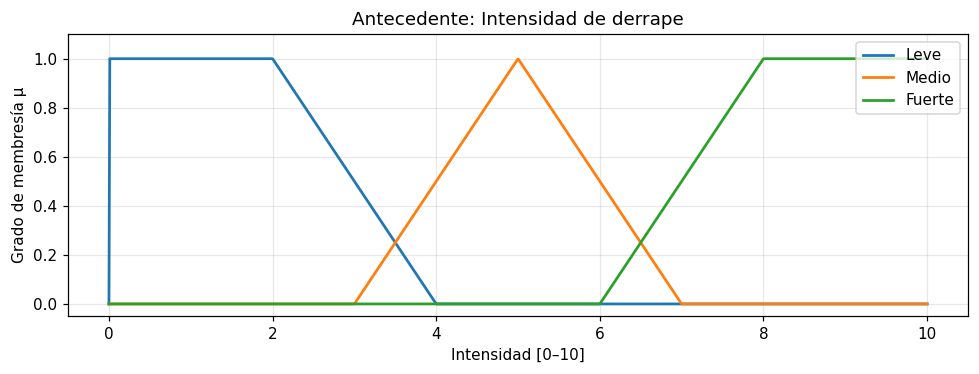


[Resultado] Antecedente 1 — Intensidad de derrape

Se definen tres conjuntos lingüísticos sobre el universo [0, 10]:

  • Leve   (trapezoidal): μ=1 en [0,2], decae a 0 en x=4. Modela situaciones donde el vehículo apenas pierde adherencia.
  • Medio  (triangular) : pico en x = 5, activo entre [3, 7]. Representa un derrape perceptible pero aún controlable. 
  • Fuerte (trapezoidal): sube de 0 a 1 entre [6, 8] y se mantiene en μ = 1 hasta x = 10. Captura situaciones críticas de pérdida de control.

  Los conjuntos se solapan en los rangos [2, 4] y [6, 8], lo que
  garantiza transiciones suaves: ante un valor intermedio (p.ej. derrape = 3.5), el sistema activa
  parcialmente tanto "Leve" como "Medio", produciendo una respuesta graduada en lugar de un salto brusco.




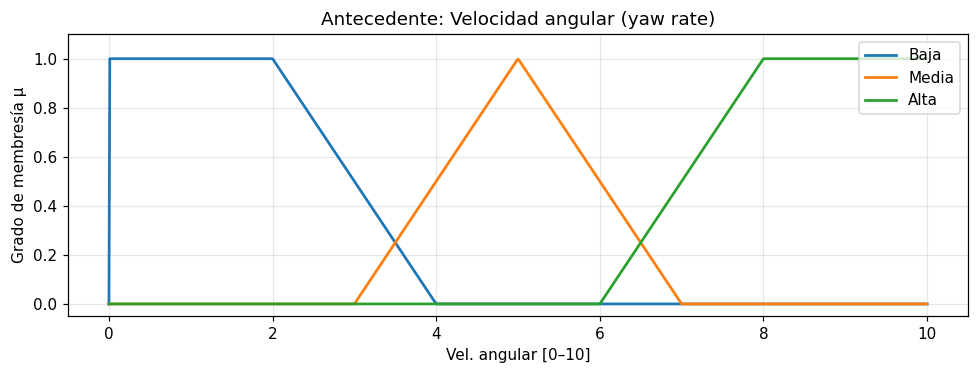


[Resultado] Antecedente 2 — Velocidad angular (yaw rate)

Estructura idéntica al antecedente 1 (Baja / Media / Alta) con los mismos
puntos de corte, ya que ambas variables comparten la misma escala [0,10]
y el mismo comportamiento cualitativo.

Ambas variables comparten la misma escala normalizada y el mismo comportamiento 
cualitativo (de ninguna a máxima intensidad), por lo que reutilizar la misma 
partición lingüística es coherente y simplifica el diseño de reglas.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de 
las reglas: "IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente 
interpretable porque los conjuntos tienen la misma semántica.




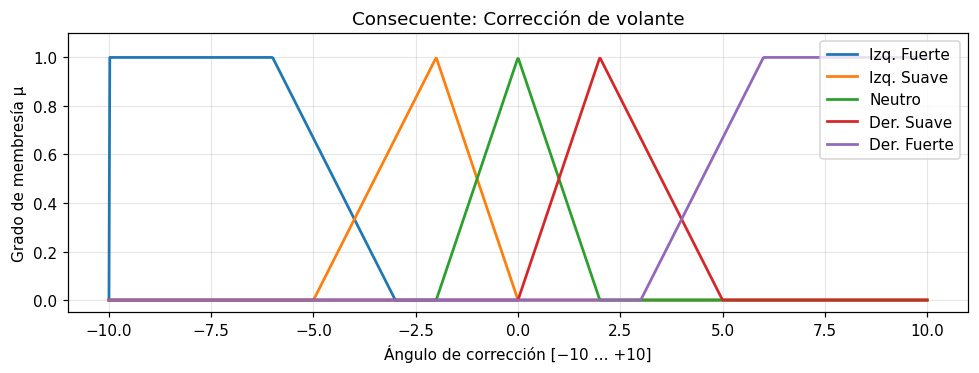


[Resultado] Consecuente 1 — Corrección de volante

Cinco conjuntos lingüísticos sobre el universo [−10, +10]:

- Izq. Fuerte (trapezoidal): μ = 1 en [−10, −6], decae hasta −3. Corrección máxima hacia la izquierda.
- Izq. Suave (triangular): pico en x = −2, activo en [−5, 0].
- Neutro (triangular): pico en x = 0, activo en [−2, 2]. Sin corrección.
- Der. Suave (triangular): pico en x = 2, activo en [0, 5].
- Der. Fuerte (trapezoidal): sube en [3, 6], μ = 1 en [6, 10]. Corrección máxima hacia la derecha.

Se utilizan 5 conjuntos porque a diferencia de las variables de intensidad (que solo necesitan magnitud), 
el volante tiene dirección, por lo tanto, se necesita representar tanto el sentido (izquierda/derecha) 
como la magnitud (suave/fuerte), además del estado neutro, lo que justifica la mayor granularidad.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de las reglas: 
"IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente interpretable porq

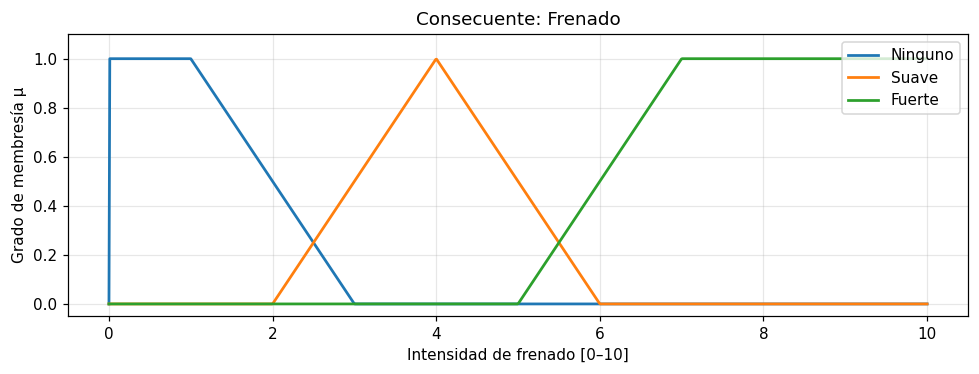


[Resultado] Consecuente 2 — Intensidad de frenado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplicar freno.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Frenado moderado.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Frenado de emergencia.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia 
  la regla "IF derrape=Leve THEN frenado=Ninguno" debe poder activar una MF 
  concreta. Si no existiera este conjunto, un derrape leve no generaría ninguna 
  salida de frenado y el centroide podría desplazarse incorrectamente.




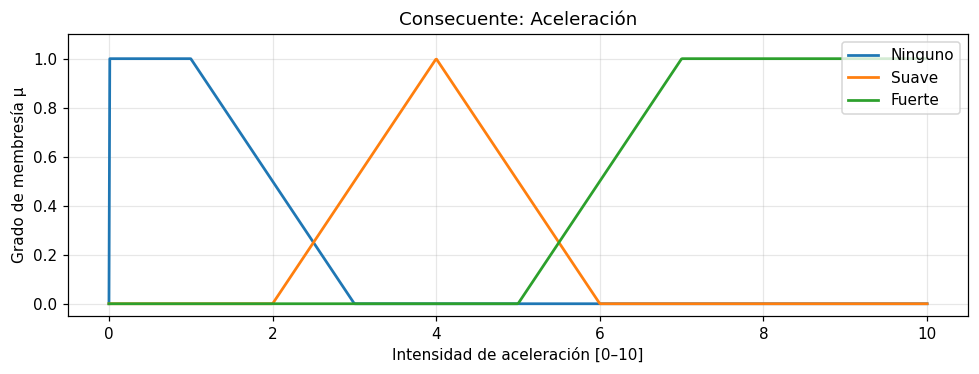


[Resultado] Consecuente 3 — Intensidad de acelerado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplica aceleración.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Aceleración parcial.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Aceleración total.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia 
  la regla "IF derrape=Leve THEN aceleracion=Ninguno" debe poder activar una MF 
  concreta. Si este conjunto existe, quiere decir que se pierde totalmente el control.


PASO 2: Funciones de pertenencia definidas y analizadas.


In [119]:
# =================================================================================
# PASO 2: Definir funciones de pertenencia
#
# A cada universo se le asignan 3–5 conjuntos lingüísticos que lo cubren.
#
# Función trapezoidal: Los valores muy bajos o muy altos merecen
# membresía máxima en un rango (no solo en un pico), por eso se usa trapmf.
#
# Función triangular en el centro: La categoría media tiene un pico definido
# y decrece simétricamente a ambos lados.
# =================================================================================

# ─── Antecedente 1: Intensidad de derrape ────────────────────────────────────
mf_der_leve   = trapmf(u_derrape, 0, 0, 2, 4)
mf_der_medio  = trimf(u_derrape,  3, 5, 7)
mf_der_fuerte = trapmf(u_derrape, 6, 8, 10, 10)

plot_mf(u_derrape,
        {"Leve": mf_der_leve, "Medio": mf_der_medio, "Fuerte": mf_der_fuerte},
        "Antecedente: Intensidad de derrape",
        "Intensidad [0–10]")

print("""
[Resultado] Antecedente 1 — Intensidad de derrape

Se definen tres conjuntos lingüísticos sobre el universo [0, 10]:

  • Leve   (trapezoidal): μ=1 en [0,2], decae a 0 en x=4. Modela situaciones donde el vehículo apenas pierde adherencia.
  • Medio  (triangular) : pico en x = 5, activo entre [3, 7]. Representa un derrape perceptible pero aún controlable. 
  • Fuerte (trapezoidal): sube de 0 a 1 entre [6, 8] y se mantiene en μ = 1 hasta x = 10. Captura situaciones críticas de pérdida de control.

  Los conjuntos se solapan en los rangos [2, 4] y [6, 8], lo que
  garantiza transiciones suaves: ante un valor intermedio (p.ej. derrape = 3.5), el sistema activa
  parcialmente tanto "Leve" como "Medio", produciendo una respuesta graduada en lugar de un salto brusco.

""")

# ─── Antecedente 2: Velocidad angular (yaw rate) ─────────────────────────────
# La velocidad angular indica cuán rápido rota el chasis.
# Un yaw rate alto con derrape fuerte es la situación más peligrosa.
mf_va_baja  = trapmf(u_vel_ang, 0, 0, 2, 4)
mf_va_media = trimf(u_vel_ang,  3, 5, 7)
mf_va_alta  = trapmf(u_vel_ang, 6, 8, 10, 10)

plot_mf(u_vel_ang,
        {"Baja": mf_va_baja, "Media": mf_va_media, "Alta": mf_va_alta},
        "Antecedente: Velocidad angular (yaw rate)",
        "Vel. angular [0–10]")

print("""
[Resultado] Antecedente 2 — Velocidad angular (yaw rate)

Estructura idéntica al antecedente 1 (Baja / Media / Alta) con los mismos
puntos de corte, ya que ambas variables comparten la misma escala [0,10]
y el mismo comportamiento cualitativo.

Ambas variables comparten la misma escala normalizada y el mismo comportamiento 
cualitativo (de ninguna a máxima intensidad), por lo que reutilizar la misma 
partición lingüística es coherente y simplifica el diseño de reglas.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de 
las reglas: "IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente 
interpretable porque los conjuntos tienen la misma semántica.

""")

# ─── Consecuente 1: Corrección de volante ────────────────────────────────────
# Se aplican 5 conjuntos porque la corrección de volante tiene dirección (izq/der)
# y magnitud (suave/fuerte), más un estado neutro → requiere mayor granularidad.
# Positivo = girar hacia la derecha, negativo = hacia la izquierda.
mf_vol_izq_fuerte = trapmf(u_volante, -10, -10, -6, -3)
mf_vol_izq_suave  = trimf(u_volante,  -5,  -2,  0)
mf_vol_neutro     = trimf(u_volante,  -2,   0,  2)
mf_vol_der_suave  = trimf(u_volante,   0,   2,  5)
mf_vol_der_fuerte = trapmf(u_volante,  3,   6,  10, 10)

plot_mf(u_volante,
        {"Izq. Fuerte": mf_vol_izq_fuerte, "Izq. Suave": mf_vol_izq_suave,
         "Neutro": mf_vol_neutro,
         "Der. Suave": mf_vol_der_suave, "Der. Fuerte": mf_vol_der_fuerte},
        "Consecuente: Corrección de volante",
        "Ángulo de corrección [−10 … +10]")

print("""
[Resultado] Consecuente 1 — Corrección de volante

Cinco conjuntos lingüísticos sobre el universo [−10, +10]:

- Izq. Fuerte (trapezoidal): μ = 1 en [−10, −6], decae hasta −3. Corrección máxima hacia la izquierda.
- Izq. Suave (triangular): pico en x = −2, activo en [−5, 0].
- Neutro (triangular): pico en x = 0, activo en [−2, 2]. Sin corrección.
- Der. Suave (triangular): pico en x = 2, activo en [0, 5].
- Der. Fuerte (trapezoidal): sube en [3, 6], μ = 1 en [6, 10]. Corrección máxima hacia la derecha.

Se utilizan 5 conjuntos porque a diferencia de las variables de intensidad (que solo necesitan magnitud), 
el volante tiene dirección, por lo tanto, se necesita representar tanto el sentido (izquierda/derecha) 
como la magnitud (suave/fuerte), además del estado neutro, lo que justifica la mayor granularidad.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de las reglas: 
"IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente interpretable porque los conjuntos 
tienen la misma semántica.

""")

# ─── Consecuente 2: Intensidad de frenado ────────────────────────────────────
# Se incluye frenado porque en derrapes severos reducir velocidad es esencial.
# En RWD, frenar agresivamente en derrape medio puede empeorar el sobreviraje.
mf_freno_ninguno = trapmf(u_frenado, 0, 0, 1, 3)
mf_freno_suave   = trimf(u_frenado,  2, 4, 6)
mf_freno_fuerte  = trapmf(u_frenado, 5, 7, 10, 10)

plot_mf(u_frenado,
        {"Ninguno": mf_freno_ninguno, "Suave": mf_freno_suave, "Fuerte": mf_freno_fuerte},
        "Consecuente: Frenado",
        "Intensidad de frenado [0–10]")

print("""
[Resultado] Consecuente 2 — Intensidad de frenado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplicar freno.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Frenado moderado.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Frenado de emergencia.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia 
  la regla "IF derrape=Leve THEN frenado=Ninguno" debe poder activar una MF 
  concreta. Si no existiera este conjunto, un derrape leve no generaría ninguna 
  salida de frenado y el centroide podría desplazarse incorrectamente.

""")

# ─── Consecuente 3: Intensidad de aceleración ────────────────────────────────────
# Se incluye aceleración porque en derrapes es importante maniobrar la aceleración para
# dejar de aceleración.

mf_aceleracion_ninguno = trapmf(u_aceleracion, 0, 0, 1, 3)
mf_aceleracion_suave   = trimf(u_aceleracion,  2, 4, 6)
mf_aceleracion_fuerte  = trapmf(u_aceleracion, 5, 7, 10, 10)

plot_mf(u_aceleracion,
        {"Ninguno": mf_aceleracion_ninguno, "Suave": mf_aceleracion_suave, "Fuerte": mf_aceleracion_fuerte},
        "Consecuente: Aceleración",
        "Intensidad de aceleración [0–10]")

print("""
[Resultado] Consecuente 3 — Intensidad de acelerado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplica aceleración.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Aceleración parcial.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Aceleración total.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia 
  la regla "IF derrape=Leve THEN aceleracion=Ninguno" debe poder activar una MF 
  concreta. Si este conjunto existe, quiere decir que se pierde totalmente el control.

""")        


print("PASO 2: Funciones de pertenencia definidas y analizadas.")

Resultado general paso 2: 

Todos los universos en este diseño están completamente cubiertos (no hay zonas donde ningún conjunto tenga μ > 0), 
los solapamientos son adecuados (~30–40% de superposición entre conjuntos adyacentes), y las formas trapezoidales 
en los extremos evitan que valores fuera del rango esperado queden sin representación.

In [ ]:
# -----------------------------------------------------------------------------
# PASO 3: Sistema de control difuso
# -----------------------------------------------------------------------------

def infer_skid_control(derrape_val: float, vel_ang_val: float, mode: str = "FWD") -> dict:
    """
    Sistema de control difuso para derrape vehicular.
    
    Parámetros
    ----------
    derrape_val : float — intensidad de derrape [0, 10]
    vel_ang_val : float — velocidad angular [0, 10]
    mode        : str   — 'FWD' (tracción delantera) | 'RWD' (tracción trasera)
    
    Retorna
    -------
    dict con los valores nítidos defuzzificados: correccion_volante, frenado

    Flujo interno
    -------
      1. Fuzzificación   → interpolar μ de cada entrada en sus MF
      2. Evaluación de reglas → AND = min(), OR = max()
      3. Agregación      → cortar MF de salida con np.fmin, unir con np.fmax
      4. Defuzzificación → centroide sobre el conjunto agregado

    """
    # ─── 1. Fuzzificación: Calcular μ para cada valor de entrada ───────────────────
    # np.interp evalúa el grado de membresía del valor de entrada en cada
    # función de membresía previamente definida.
    # Las MF ya están muestreadas en el universo;
    # interpolar es más eficiente y evita duplicar código.

    mu_der = {
        "leve":   float(np.interp(derrape_val,  u_derrape,  mf_der_leve)),
        "medio":  float(np.interp(derrape_val,  u_derrape,  mf_der_medio)),
        "fuerte": float(np.interp(derrape_val,  u_derrape,  mf_der_fuerte)),
    }
    mu_va = {
        "baja":  float(np.interp(vel_ang_val, u_vel_ang, mf_va_baja)),
        "media": float(np.interp(vel_ang_val, u_vel_ang, mf_va_media)),
        "alta":  float(np.interp(vel_ang_val, u_vel_ang, mf_va_alta)),
    }

    # ─── 2. Definición de reglas difusas ───────────────────
    # Cada regla es de la forma IF (A AND B) THEN C.
    #   AND  → mínimo de los grados de membresía (t-norma)
    #   OR   → máximo de los grados de membresía (s-norma)
    #
    # Se usan reglas distintas por modo:
    #   FWD → la corrección es en la MISMA dirección del derrape (por convenio,
    #         asumimos derrape hacia la derecha → girar a la derecha).
    #   RWD → la corrección es en la dirección OPUESTA (contra-dirección),
    #         y el frenado en derrape medio se omite porque empeora el sobreviraje.


    # CASO A - Tracción delantera (FWD): Girar en dirección del derrape (misma dirección)
    # El derrape se asume "hacia la derecha" como positivo.
    if mode == "FWD":
        rules_volante = {
            # Leve → corrección suave a la derecha
            "der_suave":  min(mu_der["leve"],   mu_va["baja"]),
            # Medio + media VA → corrección moderada
            "der_fuerte": max(min(mu_der["medio"],  mu_va["media"]),
                              min(mu_der["fuerte"], mu_va["alta"])),
            # Si derrape fuerte pero baja velocidad → neutro (cuidado)
            "neutro":     min(mu_der["fuerte"], mu_va["baja"]),
        }
        rules_frenado = {
            # Sin derrape o leve → no frenar
            "ninguno": mu_der["leve"],
            # Derrape medio → freno suave
            "suave":   min(mu_der["medio"], mu_va["media"]),
            # Derrape fuerte y alta VA → freno fuerte
            "fuerte":  min(mu_der["fuerte"], mu_va["alta"]),
        }
        # rules_aceleracion = {
        #     # Sin derrape o leve → no frenar
        #     "ninguno": mu_der["leve"],
        #     # Derrape medio → freno suave
        #     "suave":   min(mu_der["medio"], mu_va["media"]),
        #     # Derrape fuerte y alta VA → freno fuerte
        #     "fuerte":  min(mu_der["fuerte"], mu_va["alta"]),
        # }        
    else:  # RWD

        # CASO B - Tracción trasera (RWD): el sobreviraje trasero requiere contra-dirección
        # Se gira hacia la izquierda si el derrape es a la derecha y viceversa.
        rules_volante = {
            "izq_suave":  min(mu_der["leve"],   mu_va["baja"]),
            "izq_fuerte": max(min(mu_der["medio"],  mu_va["media"]),
                              min(mu_der["fuerte"], mu_va["alta"])),
            "neutro":     min(mu_der["fuerte"], mu_va["baja"]),
        }
        rules_frenado = {
            "ninguno": mu_der["leve"],
            # RWD: NO se frena en derrape medio (empeora el sobreviraje)
            "suave":   min(mu_der["fuerte"], mu_va["media"]),
            "fuerte":  min(mu_der["fuerte"], mu_va["alta"]),
        }

    # ─── 3. Agregación: Cortar cada MF de salida al valor de activación y tomar el máximo ───────────────────
    # Se "corta" cada función de membresía de salida al nivel de activación
    # de su regla (np.fmin = implicación), y luego se unen todas las
    # salidas tomando el máximo punto a punto (np.fmax = unión difusa).
    #
    # fmin para cortar: Garantiza que la MF de salida no supere el grado
    # de activación de la regla que la disparó.
    #
    # fmax para unir: La unión difusa preserva la información de todas
    # las reglas activas sin que una cancele a otra.    

    if mode == "FWD":
        agg_volante = np.fmax(
            np.fmin(rules_volante["der_suave"],  mf_vol_der_suave),
            np.fmax(
                np.fmin(rules_volante["der_fuerte"], mf_vol_der_fuerte),
                np.fmin(rules_volante["neutro"],     mf_vol_neutro)
            )
        )
    else:
        agg_volante = np.fmax(
            np.fmin(rules_volante["izq_suave"],  mf_vol_izq_suave),
            np.fmax(
                np.fmin(rules_volante["izq_fuerte"], mf_vol_izq_fuerte),
                np.fmin(rules_volante["neutro"],     mf_vol_neutro)
            )
        )

    agg_frenado = np.fmax(
        np.fmin(rules_frenado["ninguno"], mf_freno_ninguno),
        np.fmax(
            np.fmin(rules_frenado["suave"],   mf_freno_suave),
            np.fmin(rules_frenado["fuerte"],  mf_freno_fuerte)
        )
    )

   # ─── 4. Defuzzificación: Centroide ───────────────────
   # Se calcula el centroide del conjunto difuso agregado para obtener el
   # valor nítido de salida que se enviaría al actuador (volante, frenos).

    volante_crisp = centroid_defuzz(u_volante, agg_volante)
    frenado_crisp = centroid_defuzz(u_frenado, agg_frenado)

    return {
        "mode": mode,
        "derrape": derrape_val,
        "vel_ang": vel_ang_val,
        "correccion_volante": round(volante_crisp, 3),
        "frenado": round(frenado_crisp, 3),
        "_agg_volante": agg_volante,
        "_agg_frenado": agg_frenado,
    }

print("PASO 3: Sistema de control difuso - Ejecutado")

PASO 3: Sistema de control difuso - Ejecutado


In [116]:
# -----------------------------------------------------------------------------
# PASO 4: Simulación y visualización de casos de prueba
#
# Se prueban 4 escenarios representativos que cubren distintas
# combinaciones de severidad de derrape y velocidad angular:
#
#   - (2,2) → situación controlable, respuesta mínima esperada
#   - (5,5) → situación media, prueba la zona de solapamiento de MF
#   - (8,8) → situación crítica, máxima intervención esperada
#   - (8,2) → derrape severo pero chasis casi estático → caso borde interesante
# -----------------------------------------------------------------------------

test_cases = [
    (2, 2, "Derrape leve, baja vel. angular"),
    (5, 5, "Derrape medio, vel. angular media"),
    (8, 8, "Derrape fuerte, alta vel. angular"),
    (8, 2, "Derrape fuerte, baja vel. angular"),
]

for derrape, va, descripcion in test_cases:
    print(f"\n{'═'*60}")
    print(f"  Escenario: {descripcion}")
    print(f"  Entradas → derrape={derrape}, vel_angular={va}")
    for mode in ["FWD", "RWD"]:
        res = infer_skid_control(derrape, va, mode=mode)
        dir_label = "→ DER" if res["correccion_volante"] > 0.5 else ("← IZQ" if res["correccion_volante"] < -0.5 else "NEUTRO")
        print(f"  [{mode}] Volante: {res['correccion_volante']:+.2f} {dir_label}  |  Frenado: {res['frenado']:.2f}")

print("PASO 4: Simulación y visualización de casos de prueba - Ejecutado")                



════════════════════════════════════════════════════════════
  Escenario: Derrape leve, baja vel. angular
  Entradas → derrape=2, vel_angular=2
  [FWD] Volante: +2.33 → DER  |  Frenado: 1.09
  [RWD] Volante: -2.33 ← IZQ  |  Frenado: 1.09

════════════════════════════════════════════════════════════
  Escenario: Derrape medio, vel. angular media
  Entradas → derrape=5, vel_angular=5
  [FWD] Volante: +7.18 → DER  |  Frenado: 4.00
  [RWD] Volante: -7.17 ← IZQ  |  Frenado: 5.00

════════════════════════════════════════════════════════════
  Escenario: Derrape fuerte, alta vel. angular
  Entradas → derrape=8, vel_angular=8
  [FWD] Volante: +7.18 → DER  |  Frenado: 7.96
  [RWD] Volante: -7.18 ← IZQ  |  Frenado: 7.96

════════════════════════════════════════════════════════════
  Escenario: Derrape fuerte, baja vel. angular
  Entradas → derrape=8, vel_angular=2
  [FWD] Volante: +0.00 NEUTRO  |  Frenado: 5.00
  [RWD] Volante: +0.00 NEUTRO  |  Frenado: 5.00
PASO 4: Simulación y visualización d

Análisis de resultados:

Escenario 1:
| Modo | Corrección volante | Frenado |
|------|--------------------|---------|
| FWD  | +2.33 → DER        | 1.09    |
| RWD  | -2.33 ← IZQ        | 1.09    |

  La corrección de volante es pequeña (±2.33 sobre un rango de [-10, 10]),
  coherente con un derrape apenas perceptible donde la regla dominante es
  "IF derrape=Leve AND VA=Baja THEN der_suave/izq_suave". El frenado de 1.09
  es casi nulo, reflejando correctamente la regla "IF derrape=Leve THEN frenado=Ninguno":
  el centroide cae cerca del límite superior del conjunto "Ninguno" (activo en [0,3]).
  FWD y RWD producen el mismo módulo de corrección pero en direcciones opuestas,
  lo que confirma que la lógica de contra-dirección del modo RWD está funcionando.

Escenario 2:
| Modo | Corrección volante | Frenado |
|------|--------------------|---------|
| FWD  | +7.18 → DER        | 4.00    |
| RWD  | -7.17 ← IZQ        | 5.00    |

  La corrección sube notablemente a ±7.18, activando el conjunto "Der./Izq. Fuerte".
  Esto ocurre porque derrape=5 y VA=5 caen exactamente en los picos de las MF
  "Medio" y "Media" (μ=1.0 en ambas), activando al máximo la regla de corrección
  fuerte: `min(μ_medio, μ_media) = min(1.0, 1.0) = 1.0`.

  El frenado difiere entre modos:
    - **FWD (4.00):** la regla "IF medio AND media THEN suave" se activa con μ=1.0,
    y el centroide del conjunto "Suave" (pico en x=4) cae exactamente en 4.00.
    - **RWD (5.00):** esa misma regla está desactivada por diseño (frenar en derrape
    medio empeora el sobreviraje trasero). Solo la regla de freno fuerte puede
    activarse, pero con μ bajo, por lo que el centroide se desplaza hacia la
    transición entre "Suave" y "Fuerte", resultando en 5.00.

Escenario 3:
| Modo | Corrección volante | Frenado |
|------|--------------------|---------|
| FWD  | +7.18 → DER        | 7.96    |
| RWD  | -7.18 ← IZQ        | 7.96    |

  Situación crítica: máxima intervención en ambos modos. El frenado de 7.96
  confirma que la regla "IF fuerte AND alta THEN freno=Fuerte" se activa con
  μ≈1.0 (derrape=8 y VA=8 están en la zona plana de sus MF "Fuerte" y "Alta"),
  y el centroide del conjunto "Fuerte" (plano en [7,10]) cae en ≈7.96.

  La corrección de volante (±7.18) es idéntica al escenario 2 porque la MF
  "Der./Izq. Fuerte" ya había alcanzado saturación: una vez que la regla se
  activa con μ=1.0, aumentar más la entrada no desplaza el centroide.
  Ambos modos coinciden en el frenado porque ante un derrape crítico la
  prioridad de reducir velocidad es igual independientemente del tipo de tracción.

Escenario 4:
| Modo | Corrección volante | Frenado |
|------|--------------------|---------|
| FWD  | 0.00 NEUTRO        | 5.00    |
| RWD  | 0.00 NEUTRO        | 5.00    |

  El caso borde más interesante: el vehículo derrapa con intensidad severa
  pero el chasis no está rotando (VA baja). La regla
  "IF fuerte AND baja THEN neutro" domina completamente el volante → centroide
  en 0.00, sin corrección de dirección. El sistema interpreta correctamente que
  intervenir en el volante sería contraproducente: el vehículo está derrapando
  en línea recta, no en curva, por lo que girar el volante podría desestabilizarlo.

  El frenado de 5.00 refleja la activación parcial de reglas contradictorias:
  "Ninguno" (por VA baja) y "Fuerte" (por derrape fuerte) se activan simultáneamente,
  y el centroide queda en el punto intermedio entre ambos conjuntos.
  Este resultado es idéntico en FWD y RWD porque sin rotación del chasis
  la estrategia de tracción pierde relevancia.

Interpretación general:

  El sistema responde de forma **coherente y progresiva**: a mayor derrape y
  mayor velocidad angular, mayor es la intervención tanto en volante como en frenos.

  La distinción Tracción Delantera (FWD) - Tracción Trasera (RWD) se manifiesta 
  correctamente en dos niveles:

    - Dirección del volante: siempre simétrica (mismo módulo, signo opuesto),
    lo que valida que las reglas de contra-dirección de RWD están bien implementadas.
    - Intensidad del frenado: difiere en el escenario 2 (donde la regla de
    frenado medio está desactivada en RWD) pero converge en los escenarios 3 y 4
    (donde la severidad del derrape supera la distinción de modo).

  El escenario 4 (derrape=8, VA=2) es el más revelador del diseño: demuestra que
  el sistema no reacciona mecánicamente a una sola entrada, sino que pondera
  la combinación de ambas antes de producir una salida, comportamiento que
  sería muy difícil de lograr con lógica clásica booleana.


────────────────────────────────────────────────────────────
  Gráfica — Defuzzificación modo FWD (derrape=8, VA=8)
  Izquierda : área agregada y centroide de corrección de volante
  Derecha   : área agregada y centroide de intensidad de frenado
────────────────────────────────────────────────────────────


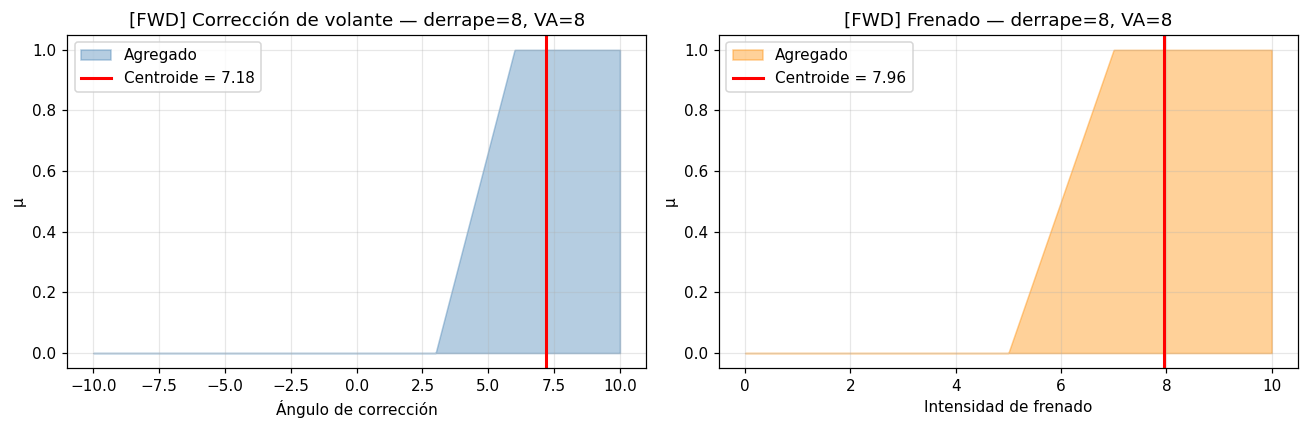


────────────────────────────────────────────────────────────
  Gráfica — Defuzzificación modo RWD (derrape=8, VA=8)
  Izquierda : área agregada y centroide de corrección de volante
  Derecha   : área agregada y centroide de intensidad de frenado
────────────────────────────────────────────────────────────


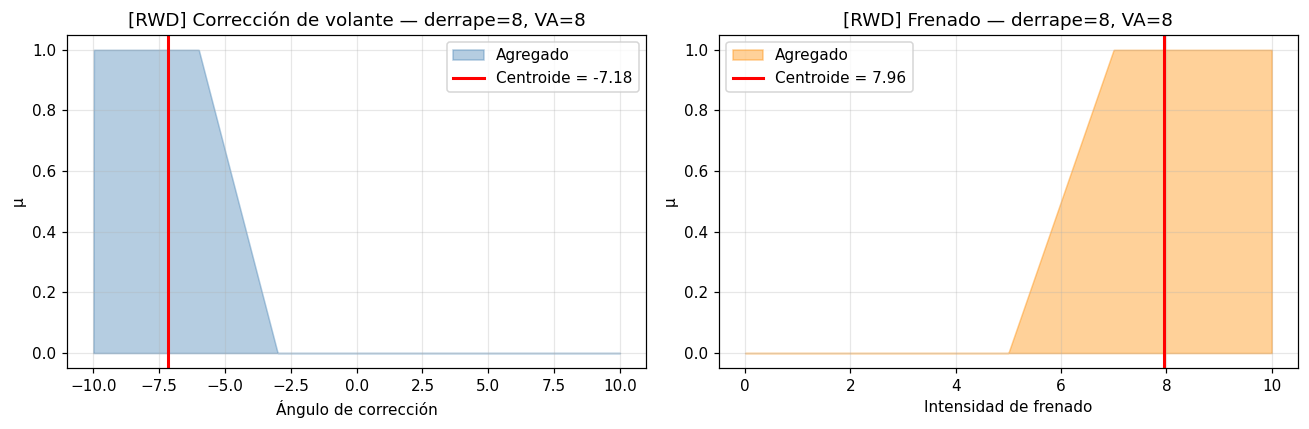

PASO 5: Visualización de la defuzzificación - Ejecutado


In [117]:
# -----------------------------------------------------------------------------
# PASO 5: Visualización de la defuzzificación
#
# Gráfica del conjunto difuso agregado (área sombreada) y la línea vertical
# del centroide para cada consecuente.
#
# La visualización permite inspeccionar cómo la agregación de reglas da forma
# al área resultante y verificar que el centroide cae donde se espera.
# -----------------------------------------------------------------------------

def plot_defuzz(result: dict):
    """Muestra los conjuntos difusos agregados y el centroide para un resultado dado."""
    mode = result["mode"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Volante
    ax = axes[0]
    ax.fill_between(u_volante, result["_agg_volante"], alpha=0.4, color="steelblue", label="Agregado")
    ax.axvline(result["correccion_volante"], color="red", linewidth=2,
               label=f"Centroide = {result['correccion_volante']:.2f}")
    ax.set_title(f"[{mode}] Corrección de volante — derrape={result['derrape']}, VA={result['vel_ang']}")
    ax.set_xlabel("Ángulo de corrección")
    ax.set_ylabel("μ")
    ax.legend()

    # Frenado
    ax = axes[1]
    ax.fill_between(u_frenado, result["_agg_frenado"], alpha=0.4, color="darkorange", label="Agregado")
    ax.axvline(result["frenado"], color="red", linewidth=2,
               label=f"Centroide = {result['frenado']:.2f}")
    ax.set_title(f"[{mode}] Frenado — derrape={result['derrape']}, VA={result['vel_ang']}")
    ax.set_xlabel("Intensidad de frenado")
    ax.set_ylabel("μ")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Visualizar caso crítico (derrape=8, VA=8)
for mode in ["FWD", "RWD"]:
    res = infer_skid_control(8, 8, mode=mode)
    print(f"\n{'─'*60}")
    print(f"  Gráfica — Defuzzificación modo {mode} (derrape=8, VA=8)")
    print(f"  Izquierda : área agregada y centroide de corrección de volante")
    print(f"  Derecha   : área agregada y centroide de intensidad de frenado")
    print(f"{'─'*60}")
    plot_defuzz(res)

print("PASO 5: Visualización de la defuzzificación - Ejecutado")

Análisis de resultados:

Se visualiza el caso crítico (derrape=8, VA=8) para ambos modos, mostrando
el área agregada (conjunto difuso resultante de todas las reglas activas)
y la línea roja del centroide (valor nítido de salida).

Gráfica 1.1: Tracción delantera - Corrección de volante

    El área agregada ocupa únicamente la zona derecha del universo [~3, 10],
    correspondiente al conjunto "Der. Fuerte". La forma es trapezoidal truncada:
    sube desde x≈3 hasta alcanzar μ=1.0 en x≈6, luego se mantiene plana hasta x=10.
    Esto indica que solo la regla de corrección fuerte a la derecha está activa,
    sin contribución de otras reglas (el área izquierda del universo está en μ=0).

    El centroide en +7.18 cae dentro de la zona plana del trapecio, ligeramente
    desplazado hacia la izquierda del centro geométrico [6,10] porque el flanco
    izquierdo del área (la rampa en [3,6]) jala el centro de masa hacia valores
    menores. Esto es un comportamiento esperado del método de centroide: el área
    triangular de la rampa tiene menos peso que la zona plana, pero desplaza
    el resultado.

Gráfica 1.2: Tracción delantera - Frenado

    El área agregada ocupa la zona derecha [~5, 10], correspondiente al conjunto
    "Fuerte". La forma es triangular-trapezoidal: sube desde x≈5, alcanza μ=1.0
    en x≈7 y se mantiene plana hasta x=10. El centroide en 7.96 cae cerca del
    inicio de la zona plana (x=7), ya que la rampa izquierda [5,7] arrastra el
    centro de masa hacia la izquierda respecto al centro geométrico de [7,10].

Gráfica 2.1: Tracción delantera - Corrección de volante

    El área agregada es el espejo exacto del caso FWD, ahora ocupando la zona
    izquierda del universo [-10, ~-3], correspondiente al conjunto "Izq. Fuerte".
    La forma trapezoidal es idéntica pero reflejada: plana en [-10,-6] y rampa
    descendente en [-6,-3].

    El centroide en -7.18 es el simétrico de +7.18, lo que confirma que las
    funciones de membresía izquierda y derecha están correctamente definidas
    como imágenes especulares. La ligera asimetría respecto al centro geométrico
    [-10,-6] se debe al mismo efecto de la rampa [-6,-3] que se observó en FWD.

Gráfica 2.2: Tracción trasera - Frenado

    El área de frenado es idéntica a la del modo FWD. Esto era esperado: ante
    derrape=8 y VA=8, ambos modos activan la misma regla de frenado fuerte con
    el mismo grado de activación (μ≈1.0), por lo que el conjunto agregado y su
    centroide son iguales independientemente del modo de tracción.


Interpretación general:

    Las cuatro gráficas muestran un patrón común: en el caso crítico (derrape=8,
    VA=8) solo una regla domina completamente cada salida, lo que produce áreas
    agregadas de forma simple (un solo conjunto activo, sin superposición de
    múltiples reglas). Esto es coherente con la lógica del sistema: cuando las
    entradas son extremas, el sistema debe dar una respuesta clara y sin ambigüedad.

    La asimetría entre el centroide y el centro geométrico del área en todos los
    paneles ilustra el principio fundamental del método de centroide: no es el
    punto medio del área, sino su centro de masa, por lo que las zonas de rampa
    (aunque pequeñas) tienen influencia real sobre el resultado final.

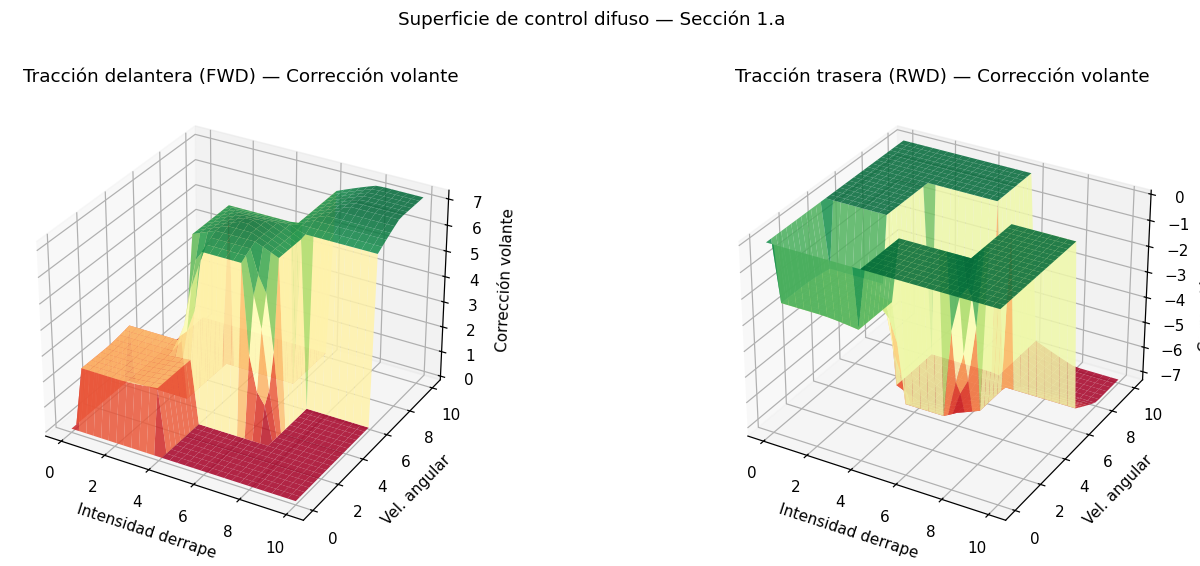

PASO 6: Superficie de control - Ejecutado


In [118]:
# -----------------------------------------------------------------------------
# PASO 6: Superficie de control
#
# Se genera un mapa 3D que muestra cómo varía la corrección de volante
# para cada combinación posible de (intensidad_derrape, velocidad_angular).
#
# La superficie de control es útil porque:
#   - Muestra cómo varía la corrección de volante en función de ambas entradas.
#   - Permite detectar discontinuidades o comportamientos inesperados del sistema.
#   - Es una herramienta estándar de validación en diseño de sistemas difusos.
#   - Facilita comparar visualmente la diferencia de estrategia FWD vs RWD.
# -----------------------------------------------------------------------------

d_range = np.linspace(0, 10, 30)
v_range = np.linspace(0, 10, 30)
D, V = np.meshgrid(d_range, v_range)

Z_fwd = np.zeros_like(D)
Z_rwd = np.zeros_like(D)

for i in range(D.shape[0]):
    for j in range(D.shape[1]):
        Z_fwd[i, j] = infer_skid_control(D[i, j], V[i, j], "FWD")["correccion_volante"]
        Z_rwd[i, j] = infer_skid_control(D[i, j], V[i, j], "RWD")["correccion_volante"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={"projection": "3d"})
for ax, Z, title in zip(axes, [Z_fwd, Z_rwd], ["Tracción delantera (FWD) — Corrección volante", "Tracción trasera (RWD) — Corrección volante"]):
    ax.plot_surface(D, V, Z, cmap="RdYlGn", alpha=0.85)
    ax.set_xlabel("Intensidad derrape")
    ax.set_ylabel("Vel. angular")
    ax.set_zlabel("Corrección volante")
    ax.set_title(title)
plt.suptitle("Superficie de control difuso — Sección 1.a", y=1.01)
plt.tight_layout()
plt.show()

print("PASO 6: Superficie de control - Ejecutado")

Análisis de resultados:

La superficie de control mapea la corrección de volante para cada combinación
posible de intensidad de derrape [0,10] y velocidad angular [0,10].
El color codifica la magnitud: verde = corrección máxima, rojo/naranja = mínima
(neutro o corrección pequeña).

Gráfica tracción delantera izquierda - Corrección de volante (rango [0, +7.18])

    La superficie revela tres zonas claramente diferenciadas:

    **Zona roja/naranja (derrape bajo, cualquier VA):** corrección cercana a 0.
    Cuando el derrape es leve (x ≈ 0–3), el sistema apenas interviene en el
    volante independientemente de la velocidad angular. El vehículo no necesita
    corrección activa.

    **Zona de transición (derrape ≈ 3–6):** la superficie sube bruscamente hacia
    valores altos (~7), especialmente cuando la velocidad angular es media-alta.
    Esta rampa pronunciada refleja el solapamiento entre las MF "Leve"-"Medio"
    y la activación creciente de la regla de corrección fuerte.

    **Zona verde (derrape alto + VA alta):** corrección máxima sostenida (~7.18).
    La superficie se aplana porque la MF "Fuerte" ya está saturada (μ=1.0):
    aumentar más el derrape o la VA no produce mayor corrección, el sistema
    ya está al límite de su respuesta.

    **Zona naranja inferior (derrape alto + VA baja):** caída a 0 (NEUTRO).
    Esta es la zona del escenario 4: derrape severo sin rotación del chasis.
    La regla "IF fuerte AND baja THEN neutro" suprime la corrección, creando
    el escalón visible en la esquina frontal-izquierda de la superficie.

Gráfica tracción trasera derecha - Corrección de volante (rango [-7.18, 0])

    La superficie es el reflejo especular exacto de FWD en el eje Z: misma
    forma, mismas zonas, pero con signo negativo en toda la corrección.
    Esto confirma que la implementación de contra-dirección en RWD es
    matemáticamente consistente con FWD: las mismas reglas, los mismos
    umbrales, solo cambia el conjunto de salida activado (izquierda vs derecha).

    El escalón en la esquina (derrape alto + VA baja) también aparece en RWD
    con valor 0, validando que el comportamiento neutro ante derrape en línea
    recta es independiente del modo de tracción.

Interpretación general:

La superficie de control revela dos características importantes del sistema:

    **No linealidad controlada:** la respuesta no crece linealmente con las
    entradas. Hay una transición brusca alrededor de derrape ≈ 4–6 donde
    el sistema "decide" pasar de intervención mínima a máxima. Esto es
    producto del solapamiento de las MF y es deseable: evita micro-correcciones
    innecesarias ante derrapes leves.

    **Comportamiento de saturación:** la zona verde plana demuestra que el
    sistema tiene un techo de respuesta. Una vez que el derrape y la VA son
    suficientemente altos, el sistema ya no puede responder más fuerte,
    lo cual es realista (el volante tiene un rango físico limitado).

    La discontinuidad visible (el escalón en la esquina de VA baja + derrape
    alto) es el resultado más interesante: muestra que el sistema difuso puede
    capturar una regla de excepción ("no corrijas el volante si el chasis no
    rota") que produce un comportamiento cualitativamente diferente en una
    zona específica del espacio de entradas.

¿Cuál es el mejor?

    Para conducción cotidiana en ciudad → FWD es más seguro, porque:

        La corrección en la misma dirección del derrape es más intuitiva para el conductor promedio.
        El frenado suave en derrape medio (escenario 2: 4.00 vs 5.00 de RWD) es más conservador y predecible.
        Menor riesgo de que el conductor "sobre-corrija" siguiendo las instrucciones del sistema.

    Para conducción deportiva o a alta velocidad → RWD permite más control, porque:

        La contra-dirección, aunque contraintuitiva, estabiliza el chasis más eficientemente en sobreviraje.
        Desactivar el frenado en derrape medio evita que las ruedas traseras pierdan aún más tracción.
        Un piloto entrenado puede aprovechar esa respuesta para recuperar el vehículo con mayor precisión.

Lo que sí es claro en ambos casos:

El escenario 4 (derrape=8, VA=2) produce NEUTRO en volante para los dos modos, lo que significa que ante un 
derrape en línea recta, ninguno de los dos sistemas interviene en la dirección — reducen velocidad y esperan, 
que es la respuesta físicamente correcta.

Las superficies 3D muestran que RWD no es "mejor" ni "peor", sino especular: misma lógica, dirección opuesta.

# ==============================================================
# SECCIÓN 1.b: Aplicación de lógica difusa en entorno de trabajo
# ==============================================================

# Sistema difuso para evaluación de proyectos de desarrollo

## Descripción del problema

En el contexto de la evaluación ex-post de proyectos de desarrollo,
determinar el nivel de eficiencia y efectividad de ejecución de un
proyecto no es una decisión binaria. Un proyecto puede haber cumplido
sus metas financieras pero haber tenido bajo impacto social, o haber
ejecutado bien institucionalmente pero con riesgos ambientales no
gestionados. La lógica difusa permite capturar esta naturaleza
multidimensional y gradual de la evaluación.

## Objetivo del sistema

Diseñar un sistema de inferencia difusa tipo Mamdani que, a partir de
cinco variables de entrada que caracterizan la ejecución de un proyecto,
produzca un puntaje de eficiencia y efectividad en escala [0, 10],
donde 0 representa ejecución deficiente y 10 representa ejecución sobresaliente.

## Variables del sistema

### Antecedentes (entradas)

| Variable                          | Descripción                                                        | Rango   |
|-----------------------------------|--------------------------------------------------------------------|---------|
| `impacto_social`                  | Grado en que el proyecto benefició a la población objetivo         | [0, 10] |
| `viabilidad_financiera`           | Nivel de eficiencia en el uso de los recursos asignados            | [0, 10] |
| `capacidad_institucional`         | Fortaleza del ejecutor para gestionar y sostener el proyecto       | [0, 10] |
| `riesgo_ambiental`                | Nivel de impacto ambiental negativo generado (0=ninguno, 10=alto)  | [0, 10] |
| `cumplimiento_metas`              | Porcentaje de objetivos e indicadores alcanzados al cierre         | [0, 10] |

> **Nota sobre `riesgo_ambiental`:** esta variable tiene semántica inversa
> respecto a las demás: un valor alto es negativo para la evaluación.
> Esto se maneja en el diseño de las reglas difusas, no en el universo.

### Consecuente (salida)

| Variable                          | Descripción                                                        | Rango   |
|-----------------------------------|--------------------------------------------------------------------|---------|
| `eficiencia_efectividad`          | Puntaje global de eficiencia y efectividad de ejecución            | [0, 10] |

Con conjuntos lingüísticos: **Deficiente**, **Regular**, **Aceptable**, **Bueno**, **Sobresaliente**.

## Pipeline de resolución propuesto

Para resolver este sistema se seguirían las mismas 4 etapas del pipeline
Mamdani aplicado en la Sección 1.a:

**1. Fuzzificación**
Cada valor nítido de entrada (p.ej. impacto_social = 6.5) se evalúa en
sus funciones de membresía para obtener los grados μ correspondientes.
Se usarán funciones trapezoidales en los extremos y triangulares en los
valores intermedios, igual que en la Sección 1.a.

**2. Evaluación de reglas**
Se definen reglas IF–THEN que combinan las cinco variables de entrada.
Por ejemplo:
- IF impacto_social=Alto AND cumplimiento_metas=Alto AND riesgo_ambiental=Bajo
  THEN eficiencia_efectividad=Sobresaliente
- IF viabilidad_financiera=Bajo AND capacidad_institucional=Bajo
  THEN eficiencia_efectividad=Deficiente
El operador AND se implementa como mínimo (t-norma), el OR como máximo (s-norma).

**3. Agregación**
Las salidas de todas las reglas activas se combinan con np.fmin
(implicación de Mamdani) y np.fmax (unión difusa), produciendo un
único conjunto difuso de salida.

**4. Defuzzificación**
Se aplica el método del centroide sobre el conjunto agregado para
obtener el puntaje nítido final de eficiencia y efectividad.

In [ ]:
# -----------------------------------------------------------------------------
# PASO 1: Definir universos de discurso
#
# Todas las variables se normalizan en la escala [0, 10] para homogeneidad.
# Se usan 1000 puntos por universo para garantizar precisión en el centroide.
#
# Excepción: riesgo_ambiental tiene semántica inversa (mayor valor = peor
# desempeño). Esto NO se corrige en el universo sino en las reglas difusas,
# donde un riesgo "Alto" activa consecuentes de baja eficiencia.
# -----------------------------------------------------------------------------

u_impacto_social        = np.linspace(0, 10, 1000)  # Beneficio a población objetivo
u_viabilidad_financiera = np.linspace(0, 10, 1000)  # Eficiencia en uso de recursos
u_capacidad_inst        = np.linspace(0, 10, 1000)  # Fortaleza institucional del ejecutor
u_riesgo_ambiental      = np.linspace(0, 10, 1000)  # Impacto ambiental negativo (inverso)
u_cumplimiento_metas    = np.linspace(0, 10, 1000)  # Objetivos e indicadores alcanzados
u_eficiencia            = np.linspace(0, 10, 1000)  # Salida: puntaje de eficiencia global

print("""
Universos de discurso definidos — Sección 1.b

  Antecedentes (entradas):
    · impacto_social        : [0, 10] — 0=sin impacto,       10=impacto máximo
    · viabilidad_financiera : [0, 10] — 0=uso ineficiente,   10=uso óptimo
    · capacidad_inst        : [0, 10] — 0=ejecutor débil,    10=ejecutor sólido
    · riesgo_ambiental      : [0, 10] — 0=sin riesgo,        10=riesgo crítico (semántica inversa)
    · cumplimiento_metas    : [0, 10] — 0=ninguna meta lograda, 10=todas las metas logradas

  Consecuente (salida):
    · eficiencia            : [0, 10] — 0=deficiente, 10=sobresaliente

  Siguiente paso: definir las funciones de membresía para cada universo
  y construir la base de reglas IF-THEN que relacione las entradas con
  el puntaje de eficiencia y efectividad.
""")

print("SECCIÓN 1.b — PASO 1: Universos de discurso definidos.")


Universos de discurso definidos — Sección 1.b

  Antecedentes (entradas):
    · impacto_social        : [0, 10] — 0=sin impacto,       10=impacto máximo
    · viabilidad_financiera : [0, 10] — 0=uso ineficiente,   10=uso óptimo
    · capacidad_inst        : [0, 10] — 0=ejecutor débil,    10=ejecutor sólido
    · riesgo_ambiental      : [0, 10] — 0=sin riesgo,        10=riesgo crítico (semántica inversa)
    · cumplimiento_metas    : [0, 10] — 0=ninguna meta lograda, 10=todas las metas logradas

  Consecuente (salida):
    · eficiencia            : [0, 10] — 0=deficiente, 10=sobresaliente

  Siguiente paso: definir las funciones de membresía para cada universo
  y construir la base de reglas IF-THEN que relacione las entradas con
  el puntaje de eficiencia y efectividad.

SECCIÓN 1.b — PASO 1: Universos de discurso definidos.


"""
# Sección 2: Experimentación con PSO

El **Particle Swarm Optimization (PSO)** es un algoritmo metaheurístico inspirado en el
comportamiento colectivo de bandadas de aves o bancos de peces. Se basa en la idea de 
que un grupo de agentes ("partículas") puede encontrar la solución óptima a un problema 
explorando el espacio de búsqueda de forma colaborativa.

Cada partícula representa una solución candidata y se mueve por el espacio de búsqueda
guiada por dos fuerzas:

- Memoria cognitiva: la partícula recuerda su mejor posición personal (pBest).
- Inteligencia social: la partícula es atraída por la mejor posición encontrada por
  todo el enjambre (gBest).

La velocidad de cada partícula se actualiza en cada iteración como:

    v_i(t+1) = w · v_i(t)                         ← inercia (exploración vs. explotación)
             + c1 · r1 · (pBest_i - x_i(t))       ← componente cognitiva
             + c2 · r2 · (gBest   - x_i(t))       ← componente social

donde `r1`, `r2` ∈ [0,1] son números aleatorios que introducen estocasticidad.

"""

# ==============================================================
# PSO: Formación de flota de drones
# ==============================================================

### Descripción del problema
En este experimento, PSO optimiza las posiciones de los drones en un área de vuelo 2D
para que adopten una formación geométrica predefinida. El algoritmo debe resolver
simultáneamente tres objetivos:

1. Precisión geométrica: minimizar el error respecto a la forma ideal.
2. Seguridad: evitar colisiones entre drones (distancia mínima de 10 m).
3. Restricciones operativas: mantener todos los drones dentro del área de vuelo.

| Aspecto | Detalle |
|---|---|
| Drones | N unidades configurables en espacio 2D (x, y) |
| Área de vuelo | 200 m × 200 m |
| Distancia de seguridad | >= 10 m entre cualquier par de drones |
| Separación en formación | 30 m entre posiciones consecutivas |

### Formaciones disponibles y sus requisitos de N

| ID          | Nombre               | Requisito de N          | Ejemplo válido          |
|-------------|----------------------|-------------------------|-------------------------|
| line        | Línea                | Cualquier N >= 2        | 2, 5, 9, 20 ...         |
| triangle    | Triángulo equilátero | N = 3 exactamente       | 3                       |
| rectangle   | Rectángulo / Grilla  | Cualquier N >= 4        | 4(2x2), 6(2x3), 9(3x3) |
| H           | Letra H              | N >= 7 e impar          | 7, 9, 11, 13 ...        |

### Hiperparámetros PSO

| Parámetro      | Símbolo | Valor | Efecto                                        |
|----------------|---------|-------|-----------------------------------------------|
| Inercia        | W       | 0.5   | Equilibra exploración global vs. explotación  |
| Coef. cognitivo| C1      | 1.5   | Fuerza de atracción al mejor personal (pBest) |
| Coef. social   | C2      | 1.5   | Fuerza de atracción al mejor global (gBest)   |
| Vel. máxima    | V_MAX   | 10.0  | Limita el desplazamiento máximo por iteración |

In [60]:
# ==============================================================
# Librerías y configuración
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

In [120]:
# =================================================================================
# PASO 1: Definir parámetros globales
# 
# Estos valores definen el problema (drones, área) y el comportamiento del
# optimizador (tamaño del enjambre, iteraciones, hiperparámetros).
#
# NUM_DRONES es el único parámetro que se cambia para probar otra flota.
# El resto del código (formaciones, PSO, visualización) se adapta automáticamente.
#
# =================================================================================

NUM_DRONES           = 9      # Número de drones en la flota
DIMENSIONS           = 2      # Espacio 2D (x, y)
AREA_WIDTH           = 200.0  # Ancho del área de vuelo [m]
AREA_HEIGHT          = 200.0  # Alto del área de vuelo [m]
MIN_SAFE_DISTANCE    = 10.0   # Distancia mínima de seguridad entre drones [m]
FORMATION_DISTANCE_L = 30.0   # Distancia entre drones consecutivos en la formación [m]

NUM_PARTICLES        = 60     # Número de partículas en el enjambre
MAX_ITERATIONS       = 200    # Número máximo de iteraciones

# Hiperparámetros PSO
W     = 0.5     # Factor de inercia: cuánto "recuerda" cada partícula su velocidad anterior.
                #   W alto → exploración amplia; W bajo → explotación local.
C1    = 1.5     # Coeficiente cognitivo: fuerza de atracción al pBest propio.
C2    = 1.5     # Coeficiente social: fuerza de atracción al gBest global.
V_MAX = 10.0    # Velocidad máxima: evita que las partículas "salten" demasiado lejos.

print(f"Paso 1: Ejecutado - Configuración del PSO")
print(f"  Drones={NUM_DRONES}), Área={AREA_WIDTH}×{AREA_HEIGHT} m")
print(f"  Partículas={NUM_PARTICLES}, Iteraciones={MAX_ITERATIONS}")
print(f"  W={W}, C1={C1}, C2={C2}, V_MAX={V_MAX}")

Paso 1: Ejecutado - Configuración del PSO
  Drones=9), Área=200.0×200.0 m
  Partículas=60, Iteraciones=200
  W=0.5, C1=1.5, C2=1.5, V_MAX=10.0


In [121]:
# ================================================================================
# VALIDADORES DE COMPATIBILIDAD
#
# Cada formación tiene requisitos sobre cuántos drones acepta.
# Estas funciones verifican esos requisitos ANTES de correr el PSO, lanzando
# un error descriptivo y accionable si la combinación (formación, N) no es válida.
#
# Separar la validación de la construcción tiene dos ventajas:
#   1. Los mensajes de error son claros: indican qué falló y qué valores son válidos.
#   2. Se pueden chequear todas las formaciones antes de gastar tiempo de cómputo.
# ================================================================================

def _validate_line(n: int) -> None:
    """line: cualquier N >= 2."""
    if n < 2:
        raise ValueError(
            f"'line' requiere N >= 2 drones. Se recibió N={n}."
        )

def _validate_triangle(n: int) -> None:
    """triangle: exactamente 3 drones (un vértice por dron)."""
    if n != 3:
        raise ValueError(
            f"'triangle' requiere exactamente N=3 drones. Se recibió N={n}.\n"
            f"Para flotas de otro tamaño usa 'line', 'rectangle' o 'H'."
        )

def _validate_rectangle(n: int) -> tuple:
    """
    rectangle: cualquier N >= 4.
    Calcula la grilla de filas x columnas más cuadrada posible para N drones.
    Estrategia: buscar la factorización r*c=N que minimiza |c - r| (más cuadrada).

    Retorna (filas, columnas).
    """
    if n < 4:
        raise ValueError(
            f"'rectangle' requiere N >= 4 drones. Se recibió N={n}."
        )
    best = None
    for r in range(1, int(math.sqrt(n)) + 1):
        if n % r == 0:
            c = n // r
            if best is None or abs(c - r) < abs(best[1] - best[0]):
                best = (r, c)
    return best  # (filas, columnas)

def _validate_H(n: int) -> tuple:
    """
    H: N >= 7 e impar.
    La H tiene dos columnas simétricas + 1 dron en el centro de la barra.
    Estructura: N = 2 * col_size + 1, por eso N debe ser impar.
    col_size es el número de drones por columna (incluye extremos y brazos).

    Retorna (col_size, bar_size=1).
    """
    if n < 7:
        raise ValueError(
            f"'H' requiere N >= 7 drones. Se recibió N={n}.\n"
            f"Mínimo: 7 drones (columnas de 3 + centro de barra)."
        )
    if n % 2 == 0:
        raise ValueError(
            f"'H' requiere un número IMPAR de drones. Se recibió N={n} (par).\n"
            f"Valores válidos cercanos: {n-1} o {n+1}."
        )
    bar_size = 1
    col_size = (n - bar_size) // 2
    return col_size, bar_size


Verificando formaciones compatibles con N=9 drones:
  ⚠ 'triangle' no compatible con N=9: 'triangle' requiere exactamente N=3 drones. Se recibió N=9.
Para flotas de otro tamaño usa 'line', 'rectangle' o 'H'.
  ✓ Formaciones válidas: ['line', 'rectangle', 'H']



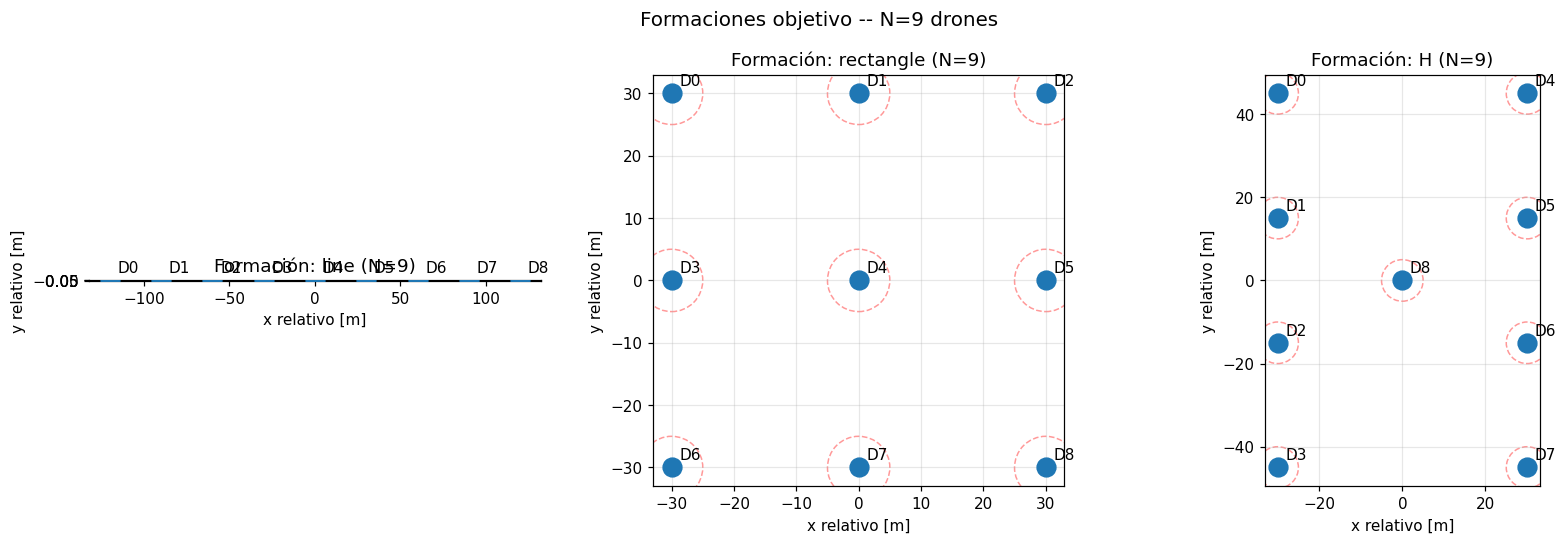

In [122]:
# ================================================================================
# FORMACIONES OBJETIVO -- posiciones relativas al centroide
#
# Expresar la formación en coordenadas relativas a (0,0) separa dos decisiones:
#   1. Qué FORMA debe adoptar la flota    -> definida aquí (geometría relativa).
#   2. DÓNDE se ubica esa forma en el área -> determinado por el PSO libremente.
#
# Esto hace la función de fitness invariante a traslaciones: el error es 0 si
# la geometría es correcta, sin importar en qué parte del área esté el centroide.
# ================================================================================


def get_target_formation_relative_positions(formation_type: str,
                                            n: int = NUM_DRONES) -> np.ndarray:
    """
    Devuelve las posiciones RELATIVAS al centroide para la formación solicitada.
    Todas las formaciones están centradas en (0, 0).

    Parámetros
    ----------
    formation_type : str -- 'line', 'triangle', 'rectangle' o 'H'
    n              : int -- número de drones

    Retorna
    -------
    np.ndarray de shape (n, DIMENSIONS)

    Lanza
    -----
    ValueError con mensaje descriptivo si n es incompatible con la formación.
    """
    targets = np.zeros((n, DIMENSIONS))
    L = FORMATION_DISTANCE_L

    if formation_type == "line":
        # ---- LÍNEA ----------------------------------------------------------
        # N drones alineados horizontalmente con separación L entre ellos.
        # El offset inicial centra la línea en x=0.
        # Funciona para cualquier N >= 2.
        #
        # Ejemplo N=5:   D0 -- D1 -- D2 -- D3 -- D4
        #                <--------- (N-1)*L -------->
        _validate_line(n)
        start_x = -(n - 1) * L / 2.0
        for i in range(n):
            targets[i, 0] = start_x + i * L
            targets[i, 1] = 0.0

    elif formation_type == "triangle":
        # ---- TRIÁNGULO EQUILÁTERO -------------------------------------------
        # Exactamente 3 drones en los vértices de un triángulo equilátero de lado L.
        # La altura del triángulo es h = (sqrt(3)/2)*L.
        # D0 en la cima, D1 y D2 en la base izquierda y derecha. Centrado en (0,0).
        _validate_triangle(n)
        h = (np.sqrt(3) / 2) * L
        targets[0, :] = [ 0,        h * 2/3]
        targets[1, :] = [-L / 2,   -h / 3  ]
        targets[2, :] = [ L / 2,   -h / 3  ]

    elif formation_type == "rectangle":
        # ---- GRILLA RECTANGULAR ---------------------------------------------
        # N drones en una grilla de filas x columnas.
        # Se elige automáticamente la factorización más cuadrada posible.
        #
        # Ejemplos:
        #   N=4  -> 2x2    N=6  -> 2x3    N=8  -> 2x4
        #   N=9  -> 3x3    N=12 -> 3x4    N=16 -> 4x4
        #
        # Los drones se indexan en orden de lectura (fila por fila, izq a der).
        rows, cols = _validate_rectangle(n)
        offset_x = -(cols - 1) * L / 2.0   # centra la grilla en x=0
        offset_y =  (rows - 1) * L / 2.0   # centra la grilla en y=0
        for idx in range(n):
            row = idx // cols
            col = idx %  cols
            targets[idx, 0] = offset_x + col * L
            targets[idx, 1] = offset_y - row * L

    elif formation_type == "H":
        # ---- FORMACIÓN EN H GENERALIZADA ------------------------------------
        # Tres partes simétricas:
        #   Columna izquierda: col_size drones en x=-L, distribuidos en y.
        #   Columna derecha  : col_size drones en x=+L, distribuidos en y.
        #   Centro de barra  : 1 dron en (0, 0).
        #
        # La barra horizontal siempre pasa por y=0 (fila media de las columnas).
        # Las columnas se distribuyen simétricamente respecto a y=0.
        #
        # Ejemplo N=9 (col_size=4):
        #   Izq: D0(-L,+1.5L)  D1(-L,+0.5L)  D2(-L,-0.5L)  D3(-L,-1.5L)
        #   Der: D4(+L,+1.5L)  D5(+L,+0.5L)  D6(+L,-0.5L)  D7(+L,-1.5L)
        #   Centro: D8(0, 0)
        #
        # Ejemplo N=7 (col_size=3):
        #   Izq: D0(-L,+L)  D1(-L,0)  D2(-L,-L)
        #   Der: D3(+L,+L)  D4(+L,0)  D5(+L,-L)
        #   Centro: D6(0, 0)
        col_size, _ = _validate_H(n)

        # Posiciones Y de las columnas: simétricas respecto a y=0
        col_y_start = (col_size - 1) * L / 2.0
        col_ys = [col_y_start - i * L for i in range(col_size)]

        for i in range(col_size):
            targets[i, :] = [-L, col_ys[i]]           # Columna izquierda

        for i in range(col_size):
            targets[col_size + i, :] = [L, col_ys[i]] # Columna derecha

        targets[n - 1, :] = [0, 0]                    # Centro de la barra

    else:
        raise ValueError(
            f"Formación '{formation_type}' no reconocida.\n"
            f"Opciones disponibles: 'line', 'triangle', 'rectangle', 'H'."
        )

    return targets


# ---- Detección automática de formaciones compatibles con NUM_DRONES ----------
# Antes de visualizar o correr el PSO, se identifica cuáles formaciones son
# válidas para el N elegido. Las incompatibles se reportan con el motivo exacto.

def get_compatible_formations(n: int) -> list:
    """
    Retorna la lista de formaciones válidas para n drones.
    Imprime un mensaje explicativo para cada formación incompatible.
    """
    compatible = []
    validators = {
        "line":      lambda: _validate_line(n),
        "triangle":  lambda: _validate_triangle(n),
        "rectangle": lambda: _validate_rectangle(n),
        "H":         lambda: _validate_H(n),
    }
    for name, validator in validators.items():
        try:
            validator()
            compatible.append(name)
        except ValueError as e:
            print(f"  ⚠ '{name}' no compatible con N={n}: {e}")
    return compatible

print(f"\nVerificando formaciones compatibles con N={NUM_DRONES} drones:")
compatible_formations = get_compatible_formations(NUM_DRONES)
print(f"  ✓ Formaciones válidas: {compatible_formations}\n")

# ---- Visualización de las formaciones compatibles ----------------------------
n_plots = len(compatible_formations)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, formation in zip(axes, compatible_formations):
    pos = get_target_formation_relative_positions(formation, NUM_DRONES)
    ax.scatter(pos[:, 0], pos[:, 1], s=150, zorder=5)
    for i, (x, y) in enumerate(pos):
        ax.annotate(f"D{i}", (x, y), textcoords="offset points", xytext=(5, 5))
    for x, y in pos:
        c = plt.Circle((x, y), MIN_SAFE_DISTANCE / 2,
                        fill=False, linestyle="--", color="red", alpha=0.4)
        ax.add_artist(c)
    ax.set_title(f"Formación: {formation} (N={NUM_DRONES})")
    ax.set_aspect("equal")
    ax.set_xlabel("x relativo [m]")
    ax.set_ylabel("y relativo [m]")

plt.suptitle(f"Formaciones objetivo -- N={NUM_DRONES} drones", fontsize=13)
plt.tight_layout()
plt.show()


In [124]:
# ================================================================================
# FUNCIÓN DE FITNESS
#
# Cuantifica "qué tan mala" es una configuración de drones. PSO minimiza este valor.
#
#   fitness = w1*e_form + w2*p_coll + w3*p_boundary
#
#   (1) e_form     -- Error cuadrático respecto a la formación ideal (objetivo principal).
#   (2) p_coll     -- Penalización por colisiones (seguridad crítica, coef. 10.000).
#   (3) p_boundary -- Penalización por salir del área de vuelo (coef. 1.000).
# ================================================================================


def fitness_function(particle_position: np.ndarray,
                     target_relative_pos: np.ndarray,
                     n: int = NUM_DRONES) -> float:
    """
    Calcula el fitness total de una partícula (= una configuración de n drones).

    Parámetros
    ----------
    particle_position   : np.ndarray, shape (n * DIMENSIONS,)
        Vector aplanado con las coordenadas (x0,y0, x1,y1, ...) de todos los drones.
    target_relative_pos : np.ndarray, shape (n, DIMENSIONS)
        Posiciones relativas al centroide para la formación objetivo.
    n                   : int -- número de drones

    Retorna
    -------
    float -- fitness total (menor es mejor).
    """
    drone_positions = particle_position.reshape((n, DIMENSIONS))

    # (1) Error de formación
    # Se calcula respecto al centroide actual, lo que hace el error independiente
    # de dónde esté la flota dentro del área de vuelo.
    current_centroid = np.mean(drone_positions, axis=0)
    e_form = 0.0
    for i in range(n):
        ideal_pos = current_centroid + target_relative_pos[i, :]
        e_form += np.sum((drone_positions[i, :] - ideal_pos) ** 2)

    # (2) Penalización por colisión
    # Se evalúan todos los pares (i, j) con i < j para no contar dos veces.
    # Coeficiente alto (10.000) para que el PSO evite estas soluciones inseguras.
    p_coll = 0.0
    collision_penalty_value = 10_000.0
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(drone_positions[i, :] - drone_positions[j, :])
            if dist < MIN_SAFE_DISTANCE:
                p_coll += collision_penalty_value * (MIN_SAFE_DISTANCE - dist)

    # (3) Penalización por límites del área de vuelo
    # La diferencia entre la posición real y np.clip(...) es 0 dentro del área
    # y positiva fuera, proporcional a cuánto se excede el límite.
    p_boundary = 0.0
    boundary_penalty_value = 1_000.0
    for i in range(n):
        x, y = drone_positions[i, 0], drone_positions[i, 1]
        if not (0 <= x <= AREA_WIDTH):
            p_boundary += boundary_penalty_value * abs(x - np.clip(x, 0, AREA_WIDTH))
        if not (0 <= y <= AREA_HEIGHT):
            p_boundary += boundary_penalty_value * abs(y - np.clip(y, 0, AREA_HEIGHT))

    w1, w2, w3 = 1.0, 1.0, 1.0
    return w1 * e_form + w2 * p_coll + w3 * p_boundary


print("Función de fitness definida.")

Función de fitness definida.


In [125]:
# ================================================================================
# ALGORITMO PSO -- implementación principal
#
# El parámetro `n` se pasa explícitamente para que run_pso sea independiente
# del global NUM_DRONES: permite correr experimentos con distintos N en la
# misma sesión sin reasignar variables globales.
#
# ================================================================================


def run_pso(formation_type: str, n: int = NUM_DRONES, seed: int = 42,
            w: float = W, c1: float = C1, c2: float = C2,
            v_max: float = V_MAX) -> dict:
    """
    Ejecuta el algoritmo PSO para una formación y cantidad de drones dada.

    Parámetros
    ----------
    formation_type : str   -- 'line', 'triangle', 'rectangle' o 'H'
    n              : int   -- número de drones
    seed           : int   -- semilla aleatoria para reproducibilidad
    w, c1, c2      : float -- hiperparámetros PSO
    v_max          : float -- velocidad máxima

    Retorna
    -------
    dict con: formation, n, gbest_pos, gbest_fitness, fitness_history, target_rel_pos
    """
    rng = np.random.default_rng(seed)
    dim = n * DIMENSIONS   # Dimensión del espacio de búsqueda: n drones × 2 coords

    target_rel_pos = get_target_formation_relative_positions(formation_type, n)

    # ---- Inicialización del enjambre ----------------------------------------
    # Posiciones aleatorias escaladas al área de vuelo.
    # Velocidades iniciales pequeñas (10% de v_max) para favorecer exploración temprana.
    particles_pos  = rng.random((NUM_PARTICLES, dim))
    particles_pos[:, ::2]  *= AREA_WIDTH
    particles_pos[:, 1::2] *= AREA_HEIGHT
    particles_vel  = rng.random((NUM_PARTICLES, dim)) * v_max * 0.1
    pbest_pos      = np.copy(particles_pos)
    pbest_fitness  = np.full(NUM_PARTICLES, np.inf)
    gbest_pos      = np.zeros(dim)
    gbest_fitness  = np.inf
    fitness_history = []

    # ---- Bucle principal PSO ------------------------------------------------
    for iter_num in range(MAX_ITERATIONS):

        # Fase 1: Evaluación y actualización de pBest / gBest
        for i in range(NUM_PARTICLES):
            f = fitness_function(particles_pos[i], target_rel_pos, n)
            if f < pbest_fitness[i]:
                pbest_fitness[i] = f
                pbest_pos[i]     = np.copy(particles_pos[i])
            if f < gbest_fitness:
                gbest_fitness = f
                gbest_pos     = np.copy(particles_pos[i])

        fitness_history.append(gbest_fitness)

        # Fase 2: Actualización de velocidades
        # v = w*v + c1*r1*(pBest - x) + c2*r2*(gBest - x)
        r1 = rng.random((NUM_PARTICLES, dim))
        r2 = rng.random((NUM_PARTICLES, dim))
        particles_vel = (w * particles_vel
                         + c1 * r1 * (pbest_pos - particles_pos)
                         + c2 * r2 * (gbest_pos  - particles_pos))
        particles_vel = np.clip(particles_vel, -v_max, v_max)

        # Fase 3: Actualización de posiciones con clipping al área de vuelo
        particles_pos += particles_vel
        particles_pos[:, ::2]  = np.clip(particles_pos[:, ::2],  0, AREA_WIDTH)
        particles_pos[:, 1::2] = np.clip(particles_pos[:, 1::2], 0, AREA_HEIGHT)

        if (iter_num + 1) % 50 == 0:
            print(f"  [{formation_type} N={n}] Iter {iter_num+1:>3}/{MAX_ITERATIONS}  "
                  f"gBest fitness = {gbest_fitness:.2f}")

    return {
        "formation":       formation_type,
        "n":               n,
        "gbest_pos":       gbest_pos,
        "gbest_fitness":   gbest_fitness,
        "fitness_history": fitness_history,
        "target_rel_pos":  target_rel_pos,
    }


print("Función run_pso definida.")

Función run_pso definida.


In [126]:
# ================================================================================
# EJECUCIÓN
#
# Se corre PSO solo para las formaciones compatibles con NUM_DRONES.
# Al cambiar NUM_DRONES en la Celda 1, esta celda se adapta automáticamente
# porque usa la lista compatible_formations generada en la Celda 3.
#
# ================================================================================

results = {}

for formation in compatible_formations:
    print(f"\n{'--'*25}")
    print(f" Ejecutando PSO -> Formación: {formation.upper()} | N={NUM_DRONES}")
    print(f"{'--'*25}")
    res = run_pso(formation, n=NUM_DRONES)
    results[formation] = res
    print(f" Fitness final: {res['gbest_fitness']:.4f}")

print("\nPSO completado para todas las formaciones compatibles.")


--------------------------------------------------
 Ejecutando PSO -> Formación: LINE | N=9
--------------------------------------------------
  [line N=9] Iter  50/200  gBest fitness = 1098.24
  [line N=9] Iter 100/200  gBest fitness = 839.92
  [line N=9] Iter 150/200  gBest fitness = 821.83
  [line N=9] Iter 200/200  gBest fitness = 821.03
 Fitness final: 821.0269

--------------------------------------------------
 Ejecutando PSO -> Formación: RECTANGLE | N=9
--------------------------------------------------
  [rectangle N=9] Iter  50/200  gBest fitness = 1.74
  [rectangle N=9] Iter 100/200  gBest fitness = 0.00
  [rectangle N=9] Iter 150/200  gBest fitness = 0.00
  [rectangle N=9] Iter 200/200  gBest fitness = 0.00
 Fitness final: 0.0000

--------------------------------------------------
 Ejecutando PSO -> Formación: H | N=9
--------------------------------------------------
  [H N=9] Iter  50/200  gBest fitness = 0.12
  [H N=9] Iter 100/200  gBest fitness = 0.00
  [H N=9] Iter 

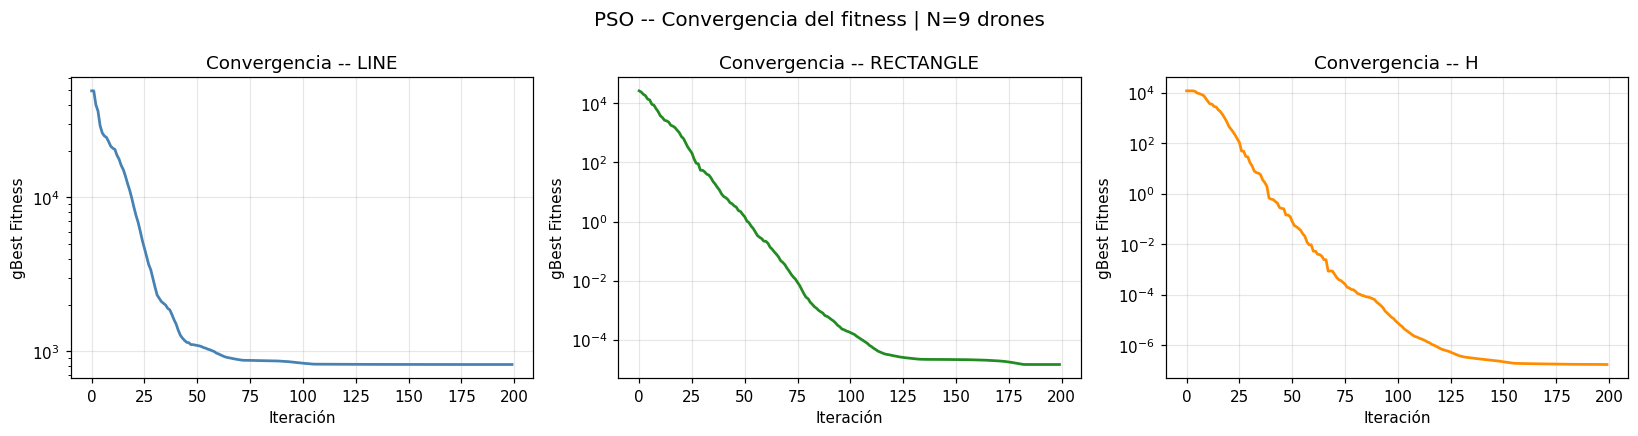


Fitness finales:
  LINE          Fitness = 821.0269
  RECTANGLE     Fitness = 0.0000
  H             Fitness = 0.0000


In [127]:
# ================================================================================
# CONVERGENCIA DEL FITNESS
#
# La curva muestra cómo evoluciona el gBest fitness iteración a iteración.
# Escala logarítmica en Y para apreciar tanto la caída rápida inicial como
# las mejoras marginales al final.
#
# Qué buscar:
#   Caída rápida inicial  -> buena exploración del espacio de búsqueda.
#   Plateau suave y tardío -> explotación eficiente de la región prometedora.
#   Plateau abrupto y temprano -> posible convergencia prematura a un mínimo local.
#
# ================================================================================


colors = {"line": "steelblue", "triangle": "purple",
          "H": "darkorange", "rectangle": "forestgreen"}

n_plots = len(compatible_formations)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, formation in zip(axes, compatible_formations):
    history = results[formation]["fitness_history"]
    ax.plot(history, color=colors.get(formation, "gray"), linewidth=1.8)
    ax.set_title(f"Convergencia -- {formation.upper()}")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("gBest Fitness")
    ax.set_yscale("log")

plt.suptitle(f"PSO -- Convergencia del fitness | N={NUM_DRONES} drones", fontsize=13)
plt.tight_layout()
plt.show()

print("\nFitness finales:")
for f in compatible_formations:
    print(f"  {f.upper():12s}  Fitness = {results[f]['gbest_fitness']:.4f}")

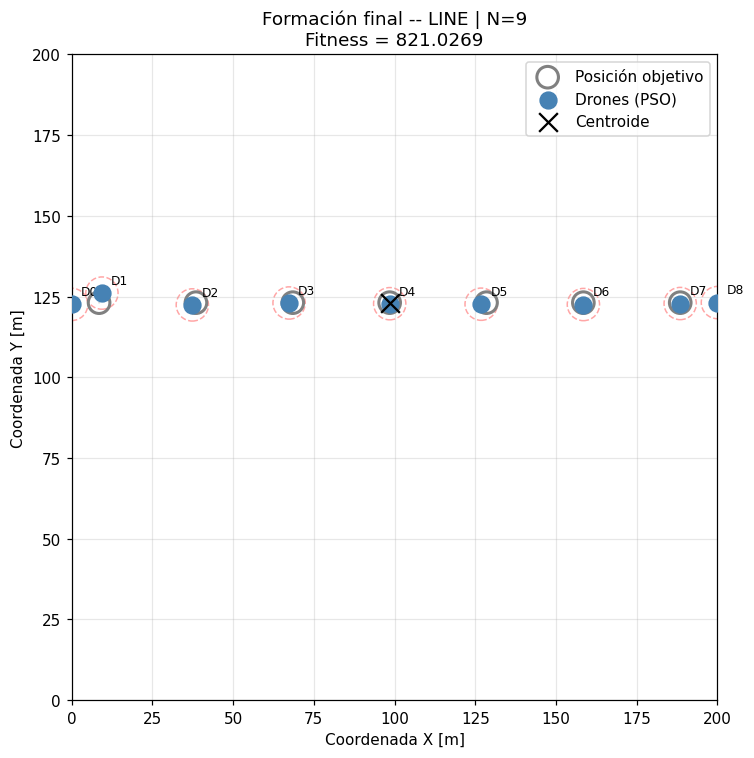

  Sin colisiones. Distancia mínima entre drones: 10.00 m


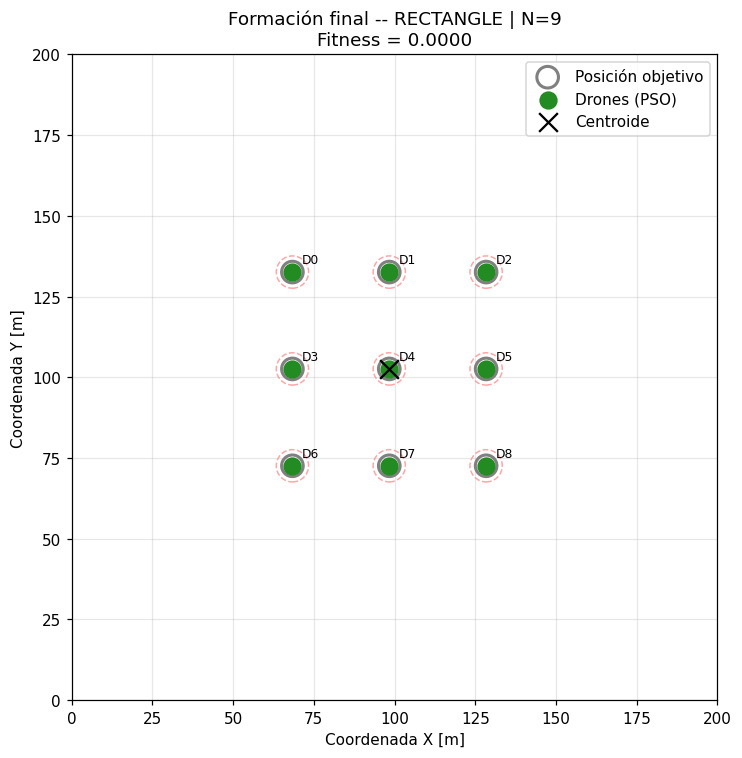

  Sin colisiones. Distancia mínima entre drones: 30.00 m


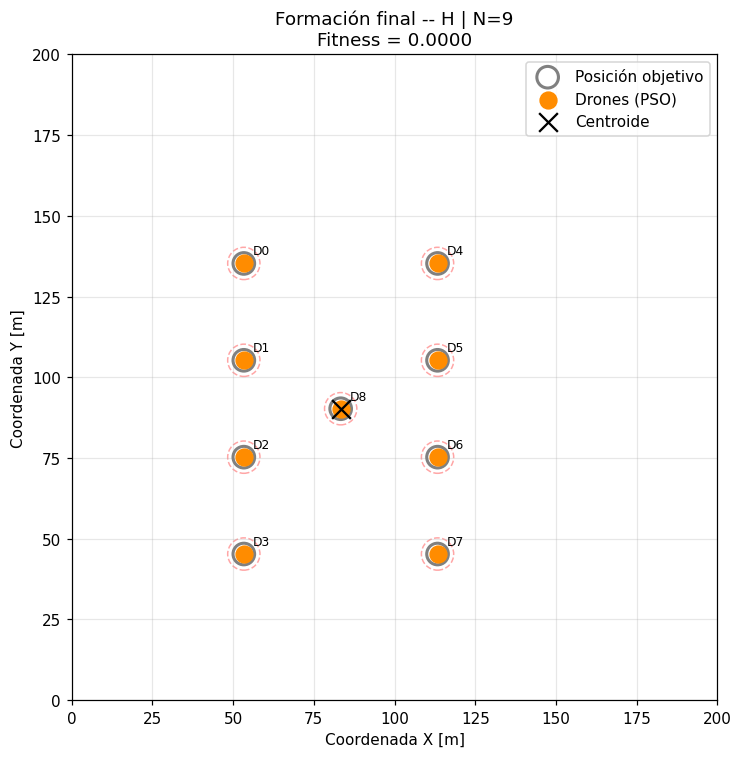

  Sin colisiones. Distancia mínima entre drones: 30.00 m


In [128]:
# ================================================================================
# FORMACIONES FINALES ENCONTRADAS POR EL PSO
#
# Para cada formación se superponen:
#   Círculos grises  -> posiciones ideales (objetivo) centradas en el centroide actual.
#   Puntos de color  -> posiciones reales encontradas por el PSO (gBest).
#   Líneas grises    -> error de cada dron respecto a su posición ideal.
#   Círculos rojos   -> zona de distancia de seguridad (radio = MIN_SAFE_DISTANCE/2).
#   Cruz negra       -> centroide de la formación encontrada.
#
# ================================================================================


def plot_final_formation(result: dict):
    """Visualiza la formación final encontrada por el PSO vs. la objetivo."""
    formation  = result["formation"]
    n          = result["n"]
    drone_pos  = result["gbest_pos"].reshape((n, DIMENSIONS))
    centroid   = np.mean(drone_pos, axis=0)
    ideal_pos  = centroid + result["target_rel_pos"]

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(ideal_pos[:, 0], ideal_pos[:, 1],
               s=200, marker="o", facecolors="none", edgecolors="gray",
               linewidths=2, label="Posición objetivo", zorder=3)
    ax.scatter(drone_pos[:, 0], drone_pos[:, 1],
               s=120, color=colors.get(formation, "gray"), zorder=5, label="Drones (PSO)")

    for i, (x, y) in enumerate(drone_pos):
        ax.annotate(f"D{i}", (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)
        c = plt.Circle((x, y), MIN_SAFE_DISTANCE / 2,
                        fill=False, linestyle="--", color="red", alpha=0.35)
        ax.add_artist(c)
        ax.plot([x, ideal_pos[i, 0]], [y, ideal_pos[i, 1]],
                color="lightgray", linewidth=1, zorder=2)

    ax.scatter(*centroid, marker="x", s=150, color="black", zorder=6, label="Centroide")
    ax.set_xlim(0, AREA_WIDTH)
    ax.set_ylim(0, AREA_HEIGHT)
    ax.set_aspect("equal")
    ax.set_title(f"Formación final -- {formation.upper()} | N={n}\n"
                 f"Fitness = {result['gbest_fitness']:.4f}")
    ax.set_xlabel("Coordenada X [m]")
    ax.set_ylabel("Coordenada Y [m]")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # Verificación de colisiones en la solución final
    colisiones = [
        (i, j, round(np.linalg.norm(drone_pos[i] - drone_pos[j]), 2))
        for i, j in combinations(range(n), 2)
        if np.linalg.norm(drone_pos[i] - drone_pos[j]) < MIN_SAFE_DISTANCE
    ]
    if colisiones:
        print(f"  Colisiones detectadas: {colisiones}")
    else:
        dist_min = min(np.linalg.norm(drone_pos[i] - drone_pos[j])
                       for i, j in combinations(range(n), 2))
        print(f"  Sin colisiones. Distancia mínima entre drones: {dist_min:.2f} m")


for formation in compatible_formations:
    plot_final_formation(results[formation])

Análisis de sensibilidad -- Formación: LINE | N=9
  Probando W = 0.2...
  [line N=9] Iter  50/200  gBest fitness = 13081.34
  [line N=9] Iter 100/200  gBest fitness = 12926.03
  [line N=9] Iter 150/200  gBest fitness = 12900.84
  [line N=9] Iter 200/200  gBest fitness = 12891.11
    Fitness final = 12891.1069
  Probando W = 0.5...
  [line N=9] Iter  50/200  gBest fitness = 1098.24
  [line N=9] Iter 100/200  gBest fitness = 839.92
  [line N=9] Iter 150/200  gBest fitness = 821.83
  [line N=9] Iter 200/200  gBest fitness = 821.03
    Fitness final = 821.0269
  Probando W = 0.9...
  [line N=9] Iter  50/200  gBest fitness = 1017.49
  [line N=9] Iter 100/200  gBest fitness = 954.74
  [line N=9] Iter 150/200  gBest fitness = 934.55
  [line N=9] Iter 200/200  gBest fitness = 932.86
    Fitness final = 932.8596


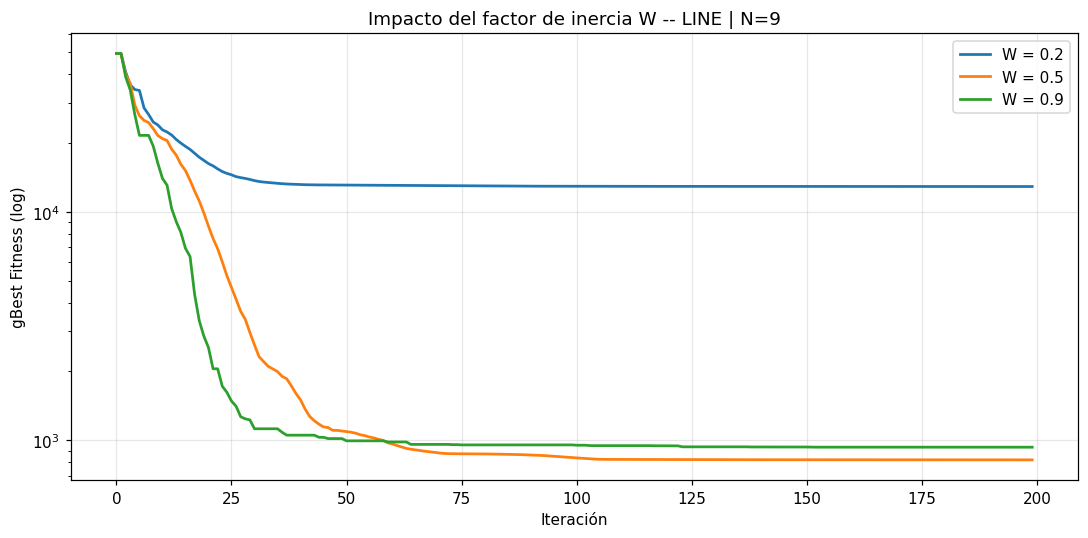


Conclusiones del análisis de sensibilidad:
  W=0.2 -> Converge rápido pero puede quedar atrapado en mínimos locales.
  W=0.5 -> Balance óptimo entre exploración y explotación (recomendado).
  W=0.9 -> Exploración amplia; necesita más iteraciones para converger.


In [129]:
# ================================================================================
# ANÁLISIS DE SENSIBILIDAD → W (factor de inercia)
#
# W controla el balance exploración / explotación:
#   W=0.9 -> exploración amplia, la partícula sigue su trayectoria actual. Converge lento.
#   W=0.5 -> balance entre ambos extremos. Valor por defecto recomendado.
#   W=0.2 -> explotación local rápida, pero riesgo de quedar atrapado en mínimos locales.
#
# Se usa la primera formación compatible con NUM_DRONES para garantizar que el
# análisis siempre sea ejecutable independientemente del N elegido.
#
# ================================================================================

formation_test = compatible_formations[0]
w_values = [0.2, 0.5, 0.9]
sensitivity_results = {}

print(f"Análisis de sensibilidad -- Formación: {formation_test.upper()} | N={NUM_DRONES}")
for w_val in w_values:
    print(f"  Probando W = {w_val}...")
    res = run_pso(formation_test, n=NUM_DRONES, seed=42, w=w_val)
    sensitivity_results[w_val] = res
    print(f"    Fitness final = {res['gbest_fitness']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for w_val in w_values:
    ax.plot(sensitivity_results[w_val]["fitness_history"],
            label=f"W = {w_val}", linewidth=1.8)
ax.set_yscale("log")
ax.set_title(f"Impacto del factor de inercia W -- {formation_test.upper()} | N={NUM_DRONES}")
ax.set_xlabel("Iteración")
ax.set_ylabel("gBest Fitness (log)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nConclusiones del análisis de sensibilidad:")
print("  W=0.2 -> Converge rápido pero puede quedar atrapado en mínimos locales.")
print("  W=0.5 -> Balance óptimo entre exploración y explotación (recomendado).")
print("  W=0.9 -> Exploración amplia; necesita más iteraciones para converger.")

Iteración 10/250, Mejor Fitness: 106315.07
Iteración 20/250, Mejor Fitness: 60214.23
Iteración 30/250, Mejor Fitness: 27628.10
Iteración 40/250, Mejor Fitness: 14930.63
Iteración 50/250, Mejor Fitness: 6835.63
Iteración 60/250, Mejor Fitness: 2101.42
Iteración 70/250, Mejor Fitness: 651.08
Iteración 80/250, Mejor Fitness: 236.83
Iteración 90/250, Mejor Fitness: 85.04
Iteración 100/250, Mejor Fitness: 37.76
Iteración 110/250, Mejor Fitness: 11.49
Iteración 120/250, Mejor Fitness: 3.26
Iteración 130/250, Mejor Fitness: 1.70
Iteración 140/250, Mejor Fitness: 0.54
Iteración 150/250, Mejor Fitness: 0.18
Iteración 160/250, Mejor Fitness: 0.07
Iteración 170/250, Mejor Fitness: 0.03
Iteración 180/250, Mejor Fitness: 0.01
Iteración 190/250, Mejor Fitness: 0.00
Iteración 200/250, Mejor Fitness: 0.00
Iteración 210/250, Mejor Fitness: 0.00
Iteración 220/250, Mejor Fitness: 0.00
Iteración 230/250, Mejor Fitness: 0.00
Iteración 240/250, Mejor Fitness: 0.00
Iteración 250/250, Mejor Fitness: 0.00

---

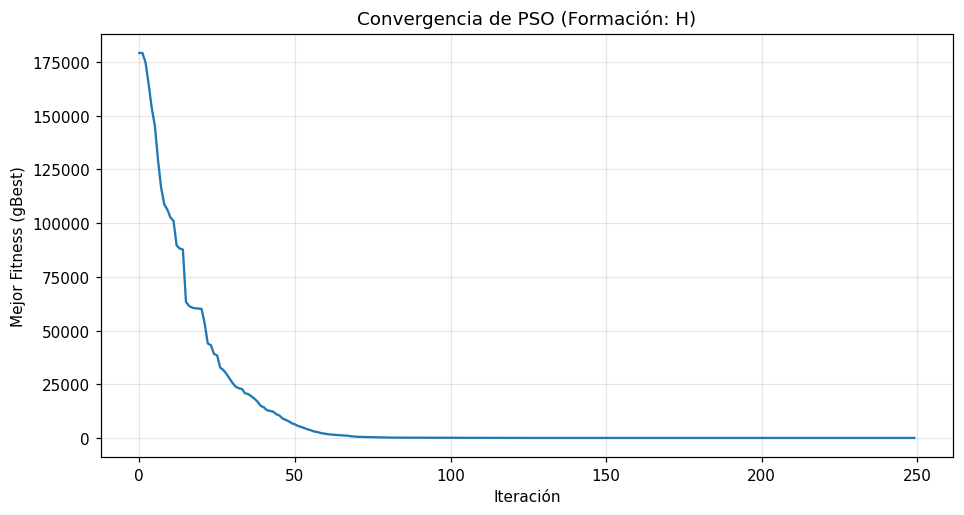

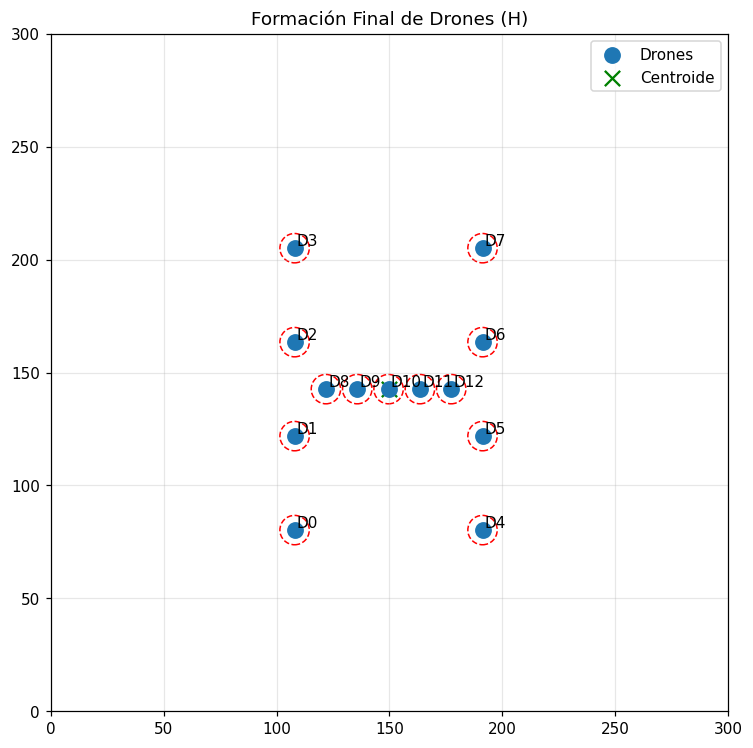

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import random
np.random.seed(42)
random.seed(42)

# ----- CONFIGURACIÓN Y PARÁMETROS DEL SISTEMA ----- #
# Definimos el tipo de formación deseada. El algoritmo buscará minimizar el error
# respecto a esta geometría específica.
TARGET_FORMATION_TYPE='H'

# ----- SELECCIÓN DE FORMACIÓN Y ASIGNACIÓN DE PARÁMETROS ----- #
# Los hiperparámetros (Partículas, Iteraciones) varían según la complejidad
# del espacio de búsqueda de cada geometría.
match TARGET_FORMATION_TYPE:
  case "Linea":
        NUM_DRONES, AREA_WIDTH, AREA_HEIGHT = 9, 150, 150
        MIN_SAFE_DISTANCE, FORMATION_DISTANCE_L = 3, 10
        NUM_PARTICLES, MAX_ITERATIONS = 40, 100
        # --- PARÁMETROS DEL ALGORITMO PSO ---
        W = 0.7          # Inercia: Controla la exploración vs explotación. Un valor medio evita oscilaciones.
        C1 = 1.2         # Coeficiente Cognitivo: Peso del aprendizaje individual (pBest).
        C2 = 1.8         # Coeficiente Social: Peso del aprendizaje colectivo (gBest).
        V_MAX = 12.0     # Velocidad Máxima: Límite físico para evitar que las partículas "salten" fuera del óptimo.
        # ----- PESOS DE LA FUNCIÓN FITNESS (MULTIOBJETIVO) ----- #
        # Aplicamos una suma ponderada para equilibrar los diferentes objetivos del enjambre.
        w1 = 1.0     # Precisión de la figura.
        w2 = 20.0    # Penalización por colisión (prioridad crítica).
        w3 = 15.0    # Penalización por límites del área de vuelo.
  case "Triangulo":
        NUM_DRONES, AREA_WIDTH, AREA_HEIGHT = 9, 150, 150
        MIN_SAFE_DISTANCE = 6
        # Ajuste dinámico de la distancia para mantener la proporción geométrica
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))
        NUM_PARTICLES, MAX_ITERATIONS = 40, 100
        # --- PARÁMETROS DEL ALGORITMO PSO ---
        W = 0.5          # Inercia: Controla la exploración vs explotación. Un valor medio evita oscilaciones.
        C1 = 1.5         # Coeficiente Cognitivo: Peso del aprendizaje individual (pBest).
        C2 = 1.5         # Coeficiente Social: Peso del aprendizaje colectivo (gBest).
        V_MAX = 10.0     # Velocidad Máxima: Límite físico para evitar que las partículas "salten" fuera del óptimo.
        # ----- PESOS DE LA FUNCIÓN FITNESS (MULTIOBJETIVO) ----- #
        # Aplicamos una suma ponderada para equilibrar los diferentes objetivos del enjambre.
        w1 = 1.0     # Precisión de la figura.
        w2 = 40.0    # Penalización por colisión (prioridad crítica).
        w3 = 10.0    # Penalización por límites del área de vuelo.
  case "Rectangulo":
        NUM_DRONES, AREA_WIDTH, AREA_HEIGHT = 12, 150, 150
        MIN_SAFE_DISTANCE = 6
        # Ajuste dinámico de la distancia para mantener la proporción geométrica
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))
        NUM_PARTICLES, MAX_ITERATIONS = 70, 100
        # --- PARÁMETROS DEL ALGORITMO PSO ---
        W = 0.5          # Inercia: Controla la exploración vs explotación. Un valor medio evita oscilaciones.
        C1 = 1.5         # Coeficiente Cognitivo: Peso del aprendizaje individual (pBest).
        C2 = 1.5         # Coeficiente Social: Peso del aprendizaje colectivo (gBest).
        V_MAX =10     # Velocidad Máxima: Límite físico para evitar que las partículas "salten" fuera del óptimo.
        # ----- PESOS DE LA FUNCIÓN FITNESS (MULTIOBJETIVO) ----- #
        # Aplicamos una suma ponderada para equilibrar los diferentes objetivos del enjambre.
        w1 = 1.0     # Precisión de la figura.
        w2 = 50.0    # Penalización por colisión (prioridad crítica).
        w3 = 10.0    # Penalización por límites del área de vuelo.
  case "H":
        NUM_DRONES, AREA_WIDTH, AREA_HEIGHT = 13, 300, 300
        MIN_SAFE_DISTANCE = 13
        # Ajuste dinámico de la distancia para mantener la proporción geométrica
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))
        NUM_PARTICLES, MAX_ITERATIONS = 120, 250
        # --- PARÁMETROS DEL ALGORITMO PSO ---
        W = 0.5          # Inercia: Controla la exploración vs explotación. Un valor medio evita oscilaciones.
        C1 = 1.8         # Coeficiente Cognitivo: Peso del aprendizaje individual (pBest).
        C2 = 1.8        # Coeficiente Social: Peso del aprendizaje colectivo (gBest).
        V_MAX = 5.0     # Velocidad Máxima: Límite físico para evitar que las partículas "salten" fuera del óptimo.
        # ----- PESOS DE LA FUNCIÓN FITNESS (MULTIOBJETIVO) ----- #
        # Aplicamos una suma ponderada para equilibrar los diferentes objetivos del enjambre.
        w1 = 2.0     # Precisión de la figura.
        w2 = 50.0    # Penalización por colisión (prioridad crítica).
        w3 = 10.0    # Penalización por límites del área de vuelo.
  case "Circulo":
        NUM_DRONES, AREA_WIDTH, AREA_HEIGHT = 13, 300, 300
        MIN_SAFE_DISTANCE = 13
        # Ajuste dinámico de la distancia para mantener la proporción geométrica
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))
        NUM_PARTICLES, MAX_ITERATIONS = 70, 170
        # --- PARÁMETROS DEL ALGORITMO PSO ---
        W = 0.6          # Inercia: Controla la exploración vs explotación. Un valor medio evita oscilaciones.
        C1 = 1.4         # Coeficiente Cognitivo: Peso del aprendizaje individual (pBest).
        C2 = 1.6         # Coeficiente Social: Peso del aprendizaje colectivo (gBest).
        V_MAX = 10.0     # Velocidad Máxima: Límite físico para evitar que las partículas "salten" fuera del óptimo.
        # ----- PESOS DE LA FUNCIÓN FITNESS (MULTIOBJETIVO) ----- #
        # Aplicamos una suma ponderada para equilibrar los diferentes objetivos del enjambre.
        w1 = 0.8     # Precisión de la figura.
        w2 = 30.0    # Penalización por colisión (prioridad crítica).
        w3 = 5.0    # Penalización por límites del área de vuelo.

DIMENSIONS = 2   # Espacio bidimensional (X, Y)

#El código de ejemplo denominado “Código para trabajar” implementa la formación triangular,
#implementar adicionalmente dos formaciones más, una formación en “H” y una formación “rectangular”.
# ----- IMPLEMENTACIÓN DE FORMACIÓN DE DRONES (MODELO RELATIVO) ----- #
# Esta función define las coordenadas ideales (objetivo) de cada dron en un plano local.
def get_target_formation_relative_positions(formation_type="line"):

    targets = np.zeros((NUM_DRONES, DIMENSIONS))

    # Formación de drones en línea
    if formation_type == "Linea":
        # Centra la línea en el origen (0,0)
        start_x = - (NUM_DRONES - 1) * FORMATION_DISTANCE_L / 2.0
        for i in range(NUM_DRONES):
            targets[i, 0] = start_x + i * FORMATION_DISTANCE_L
            targets[i, 1] = 0

     # Formación de drones en triángulo
    elif formation_type == "Triangulo":
        # Calculamos el lado del triángulo basado en el número de drones
        # Para que no queden muy pegados, el lado crece con NUM_DRONES
        lado = FORMATION_DISTANCE_L * (NUM_DRONES / 3)
        h = (np.sqrt(3) / 2) * lado

        # Vértices del triángulo
        v1 = np.array([0, h * 2/3])           # Superior
        v2 = np.array([-lado / 2, -h / 3])    # Inferior Izquierda
        v3 = np.array([lado / 2, -h / 3])     # Inferior Derecha

        # Repartimos los drones en los 3 segmentos (lados)
        drones_por_lado = NUM_DRONES // 3
        extras = NUM_DRONES % 3

        idx = 0
        # Función auxiliar para repartir puntos entre dos vértices
        def repartir_en_linea(p1, p2, n):
            return [p1 + (p2 - p1) * (i / n) for i in range(n)]

        # Lado 1: v1 a v2
        n1 = drones_por_lado + (1 if extras > 0 else 0)
        puntos = repartir_en_linea(v1, v2, n1)
        for p in puntos:
            targets[idx] = p
            idx += 1

        # Lado 2: v2 a v3
        n2 = drones_por_lado + (1 if extras > 1 else 0)
        puntos = repartir_en_linea(v2, v3, n2)
        for p in puntos:
            targets[idx] = p
            idx += 1

        # Lado 3: v3 a v1
        n3 = NUM_DRONES - idx
        puntos = repartir_en_linea(v3, v1, n3)
        for p in puntos:
            targets[idx] = p
            idx += 1

    # Formación de drones en rectángulo
    elif formation_type == "Rectangulo":
        # Calculamos una distribución lo más cuadrada posible
        # Por ejemplo, para 8 drones: 4x2. Para 16: 4x4
        cols = int(np.ceil(np.sqrt(NUM_DRONES)))
        rows = int(np.ceil(NUM_DRONES / cols))

        offset_x = (cols - 1) * FORMATION_DISTANCE_L / 2.0
        offset_y = (rows - 1) * FORMATION_DISTANCE_L / 2.0

        for i in range(NUM_DRONES):
            r = i // cols
            c = i % cols
            targets[i, 0] = c * FORMATION_DISTANCE_L - offset_x
            targets[i, 1] = r * FORMATION_DISTANCE_L - offset_y

    # Formación de drones en H
    elif formation_type == "H":
        # Dividimos los drones en 3 grupos, barra izqu, barra der y puente central
        side_count = NUM_DRONES // 3
        bridge_count = NUM_DRONES - (2 * side_count)

        # Columna Izquierda
        start_y_side = - (side_count - 1) * FORMATION_DISTANCE_L / 2.0
        for i in range(side_count):
            targets[i, :] = [-FORMATION_DISTANCE_L, start_y_side + i * FORMATION_DISTANCE_L]

        # Columna Derecha
        for i in range(side_count):
            targets[side_count + i, :] = [FORMATION_DISTANCE_L, start_y_side + i * FORMATION_DISTANCE_L]

        # Puente Central (repartido entre -FORMATION_DISTANCE_L y FORMATION_DISTANCE_L)
        if bridge_count > 0:
            # Calculamos el espacio entre los postes de la H
            bridge_step = (2 * FORMATION_DISTANCE_L) / (bridge_count + 1)
            for i in range(bridge_count):
                idx = 2 * side_count + i
                targets[idx, :] = [-FORMATION_DISTANCE_L + (i + 1) * bridge_step, 0]

    # Formación de drones en círculo
    elif formation_type == "Circulo":
        # Prueba de formación circular dinámica con el nuemro de drone
        for i in range(NUM_DRONES):
            angle = 2 * np.pi * i / NUM_DRONES
            radius = FORMATION_DISTANCE_L * (NUM_DRONES / (2 * np.pi)) # Radio proporcional al num de drones
            targets[i, 0] = radius * np.cos(angle)
            targets[i, 1] = radius * np.sin(angle)

    else:
        raise ValueError("Tipo de formación no soportado o número de drones incorrecto.")

    return targets


# ----- IMPLEMENTACIÓN DE LA FUNCIÓN FITNESS ----- #
# Cuantifica la calidad de una solución. En PSO, buscamos MINIMIZAR este valor.
def fitness_function(particle_position, target_relative_pos):
    drone_positions = particle_position.reshape((NUM_DRONES, DIMENSIONS))
    current_centroid = np.mean(drone_positions, axis=0)# El enjambre se auto-organiza respecto a su centro.

    # 1. Error de Formación: Distancia Euclidiana al cuadrado entre posición real e ideal. (E_form)
    e_form = 0
    for i in range(NUM_DRONES):
        # Posición ideal del dron i = centroide_actual + pos_relativa_ideal_i
        ideal_pos_drone_i = current_centroid + target_relative_pos[i, :]
        e_form += np.sum((drone_positions[i, :] - ideal_pos_drone_i)**2)

    # 2. Penalización por Colisión: Se activa si la distancia es menor al umbral de seguridad. (P_coll)
    p_coll = 0
    collision_penalty_value = 10000
    for i in range(NUM_DRONES):
        for j in range(i + 1, NUM_DRONES):
            dist_sq = np.sum((drone_positions[i, :] - drone_positions[j, :])**2)
            if np.sqrt(dist_sq) < MIN_SAFE_DISTANCE:
                p_coll += collision_penalty_value

    # 3. Penalización por Límites: Mantiene a los drones dentro del espacio de trabajo definido. (P_boundary)
    p_boundary = 0
    boundary_penalty_value = 1000
    for i in range(NUM_DRONES):
        if not (0 <= drone_positions[i, 0] <= AREA_WIDTH and \
                0 <= drone_positions[i, 1] <= AREA_HEIGHT):
            p_boundary += boundary_penalty_value

    total_fitness = w1 * e_form + w2 * p_coll + w3 * p_boundary
    return total_fitness


# ----- IMPLEMENTACIÓN DEL PROCESO PSO ----- #
# Inicialización de partículas y representa una configuración completa de N drones.
particles_pos = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS)
particles_pos[:, ::2] *= AREA_WIDTH   # Coordenadas X
particles_pos[:, 1::2] *= AREA_HEIGHT # Coordenadas Y

particles_vel = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS) * V_MAX * 0.1

# pBest (Personal Best): La mejor posición encontrada por cada partícula individualmente.
pbest_pos = np.copy(particles_pos)
pbest_fitness = np.array([float('inf')] * NUM_PARTICLES)

# gBest (Global Best): La mejor posición encontrada por todo el enjambre (comunicación colectiva).
gbest_pos = np.zeros(NUM_DRONES * DIMENSIONS)
gbest_fitness = float('inf')

# Selección de la formación objetivo
target_rel_pos = get_target_formation_relative_positions(TARGET_FORMATION_TYPE)
fitness_history = []

# ----- BUCLE PRINCIPAL DE OPTIMIZACIÓN ----- #
for iter_num in range(MAX_ITERATIONS):
    for i in range(NUM_PARTICLES):
        current_fitness = fitness_function(particles_pos[i], target_rel_pos)

        # Evaluación de pBest: Actualizar pBest (Mejor personal)
        if current_fitness < pbest_fitness[i]:
            pbest_fitness[i] = current_fitness
            pbest_pos[i] = np.copy(particles_pos[i])

        # Evaluación de gBest (Mejor global)
        if current_fitness < gbest_fitness:
            gbest_fitness = current_fitness
            gbest_pos = np.copy(particles_pos[i])

    fitness_history.append(gbest_fitness)

    # Actualización de Velocidad y Posición (Reglas de Movimiento Bioinspiradas)
    for i in range(NUM_PARTICLES):
        r1 = np.random.rand(NUM_DRONES * DIMENSIONS)
        r2 = np.random.rand(NUM_DRONES * DIMENSIONS)

        # Ecuación fundamental del PSO: Inercia + Componente Cognitivo + Componente Social
        cognitive_vel = C1 * r1 * (pbest_pos[i] - particles_pos[i])
        social_vel = C2 * r2 * (gbest_pos - particles_pos[i])

        particles_vel[i] = W * particles_vel[i] + cognitive_vel + social_vel

        # Control de límites físicos,  limitar velocidad y actualizar posición
        particles_vel[i] = np.clip(particles_vel[i], -V_MAX, V_MAX)
        particles_pos[i] += particles_vel[i]

        # Clipping de área al asegurar límites del área de vuelo
        particles_pos[i, ::2] = np.clip(particles_pos[i, ::2], 0, AREA_WIDTH)
        particles_pos[i, 1::2] = np.clip(particles_pos[i, 1::2], 0, AREA_HEIGHT)

    if (iter_num + 1) % 10 == 0:
        print(f"Iteración {iter_num + 1}/{MAX_ITERATIONS}, Mejor Fitness: {gbest_fitness:.2f}")


# ----- RESULTADOS Y VISUALIZACIÓN FINAL ----- #
# Estas gráficas permiten verificar visualmente la convergencia y la formación.

print("\n--- Mejor Solución Encontrada ---")
print(f"Fitness final: {gbest_fitness:.4f}")
final_drone_positions = gbest_pos.reshape((NUM_DRONES, DIMENSIONS))

# 1. Gráfico de Convergencia
plt.figure(figsize=(10, 5))
plt.plot(fitness_history)
plt.title(f'Convergencia de PSO (Formación: {TARGET_FORMATION_TYPE})')
plt.xlabel('Iteración')
plt.ylabel('Mejor Fitness (gBest)')
plt.grid(True)
plt.show()

# 2. Gráfico de Formación Final
plt.figure(figsize=(8, 8))
plt.scatter(final_drone_positions[:, 0], final_drone_positions[:, 1], s=100, label='Drones', zorder=3)

for i in range(NUM_DRONES):
    plt.text(final_drone_positions[i, 0] + 1, final_drone_positions[i, 1] + 1, f'D{i}')
    # Dibujar círculo de seguridad
    circle = plt.Circle((final_drone_positions[i, 0], final_drone_positions[i, 1]),
                        MIN_SAFE_DISTANCE / 2, color='r', fill=False, linestyle='--')
    plt.gca().add_artist(circle)

final_centroid = np.mean(final_drone_positions, axis=0)
plt.scatter(final_centroid[0], final_centroid[1], color='green', marker='x', s=100, label='Centroide')

plt.title(f'Formación Final de Drones ({TARGET_FORMATION_TYPE})')
plt.xlim(0, AREA_WIDTH)
plt.ylim(0, AREA_HEIGHT)
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()